In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Contexto del Problema

El dataset **aquifer_petrignano** corresponde a un acuífero en la llanura aluvial entre Ospedalicchio di Bastia Umbra y Petrignano (Italia). Este conjunto de datos se utiliza para analizar cómo diversas variables hidrometeorológicas afectan los niveles subterráneos del acuífero. El análisis busca entender la dinámica del acuífero y mejorar los modelos de pronóstico para la gestión sostenible del recurso hídrico.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/content/drive/MyDrive/cursos-para-dictar/UDM/07_clase/Aquifer_Petrignano.csv")
df.head()

,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
0,14/03/2006,NaN,-22.48,-22.18,NaN,NaN,NaN,NaN
1,15/03/2006,NaN,-22.38,-22.14,NaN,NaN,NaN,NaN
2,16/03/2006,NaN,-22.25,-22.04,NaN,NaN,NaN,NaN
3,17/03/2006,NaN,-22.38,-22.04,NaN,NaN,NaN,NaN
4,18/03/2006,NaN,-22.60,-22.04,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['Date', 'Rainfall_Bastia_Umbra', 'Depth_to_Groundwater_P24',
       'Depth_to_Groundwater_P25', 'Temperature_Bastia_Umbra',
       'Temperature_Petrignano', 'Volume_C10_Petrignano',
       'Hydrometry_Fiume_Chiascio_Petrignano'],
      dtype='object')

# ¿Qué es un Acuífero?

Un **acuífero** es una formación geológica subterránea que puede almacenar y transmitir agua. Se compone de rocas o sedimentos porosos, como arena o grava, que permiten la infiltración y circulación del agua. Estos sistemas son fundamentales para suministrar agua a poblaciones, cultivos e industrias, actuando como reservas naturales en la gestión de recursos hídricos.

# Descripción y Uso de Cada Variable

- **Fecha**:  
  Indica el día en el que se registran los datos, permitiendo ordenar la serie de tiempo y analizar la evolución de las variables a lo largo del tiempo.

- **Lluvia_Bastia_Umbra (mm)**:  
  Registra la cantidad de lluvia en Bastia Umbra. Su medición es fundamental para entender la recarga del acuífero, ya que la lluvia influye en la infiltración de agua al subsuelo.

- **Profundidad_al_Nivel_de_Aguas_Subterráneas_P24 (m)**:  
  Mide la profundidad hasta el nivel freático en el pozo P24. El nivel freático es la frontera entre la zona saturada y la no saturada del suelo, y su variación indica cambios en la cantidad de agua subterránea.

- **Profundidad_al_Nivel_de_Aguas_Subterráneas_P25 (m)**:  
  Similar al P24, mide la profundidad hasta el nivel freático en el pozo P25, ofreciendo otra perspectiva para evaluar la dinámica del acuífero en diferentes puntos de muestreo.

- **Temperatura_Bastia_Umbra (°C)**:  
  Registra la temperatura ambiente en Bastia Umbra. La temperatura puede afectar la tasa de evaporación y, en consecuencia, la cantidad de agua que se infiltra en el acuífero.

- **Temperatura_Petrignano (°C)**:  
  Registra la temperatura en Petrignano. Esta variable también influye en procesos como la evaporación y puede afectar la dinámica hídrica local.

- **Volumen_C10_Petrignano (m3)**:  
  Mide el volumen de agua en el punto de control C10 en Petrignano. Este valor es importante para evaluar la disponibilidad y el flujo de agua en el acuífero, así como para detectar variaciones en la cantidad de agua almacenada o transportada.

- **Hidrometría_Río_Chiascio_Petrignano**:  
  Registra el nivel hidrométrico del río Chiascio en Petrignano. Este dato es esencial para comprender cómo las variaciones en el caudal del río pueden influir en la recarga y el comportamiento del acuífero.


In [4]:
df.rename(columns={
    'Date': 'Fecha',
    'Rainfall_Bastia_Umbra': 'Lluvia_Bastia_Umbra',
    'Depth_to_Groundwater_P24': 'Profundidad_al_Nivel_de_Aguas_Subterráneas_P24',
    'Depth_to_Groundwater_P25': 'Profundidad_al_Nivel_de_Aguas_Subterráneas_P25',
    'Temperature_Bastia_Umbra': 'Temperatura_Bastia_Umbra',
    'Temperature_Petrignano': 'Temperatura_Petrignano',
    'Volume_C10_Petrignano': 'Volumen_C10_Petrignano',
    'Hydrometry_Fiume_Chiascio_Petrignano': 'Hidrometría_Río_Chiascio_Petrignano'
}, inplace=True)

df.head(1)

,Fecha,Lluvia_Bastia_Umbra,Profundidad_al_Nivel_de_Aguas_Subterráneas_P24,Profundidad_al_Nivel_de_Aguas_Subterráneas_P25,Temperatura_Bastia_Umbra,Temperatura_Petrignano,Volumen_C10_Petrignano,Hidrometría_Río_Chiascio_Petrignano
0,14/03/2006,NaN,-22.48,-22.18,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
Lluvia_Bastia_Umbra,1024
Hidrometría_Río_Chiascio_Petrignano,1024
Temperatura_Petrignano,1024
Temperatura_Bastia_Umbra,1024
Volumen_C10_Petrignano,198
Profundidad_al_Nivel_de_Aguas_Subterráneas_P24,55
Profundidad_al_Nivel_de_Aguas_Subterráneas_P25,39
Fecha,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5223 entries, 0 to 5222
Data columns (total 8 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Fecha                                           5223 non-null   object 
 1   Lluvia_Bastia_Umbra                             4199 non-null   float64
 2   Profundidad_al_Nivel_de_Aguas_Subterráneas_P24  5168 non-null   float64
 3   Profundidad_al_Nivel_de_Aguas_Subterráneas_P25  5184 non-null   float64
 4   Temperatura_Bastia_Umbra                        4199 non-null   float64
 5   Temperatura_Petrignano                          4199 non-null   float64
 6   Volumen_C10_Petrignano                          5025 non-null   float64
 7   Hidrometría_Río_Chiascio_Petrignano             4199 non-null   float64
dtypes: float64(7), object(1)
memory usage: 326.6+ KB


In [7]:
# Eliminar filas en las que no se registre la lluvia en Bastia Umbra
print("Antes de eliminar:", df.shape)

df = df[df['Lluvia_Bastia_Umbra'].notna()].reset_index(drop=True)

print("Después de eliminar:", df.shape)

Antes de eliminar: (5223, 8)
Después de eliminar: (4199, 8)


Se han eliminado las columnas **"Profundidad_al_Nivel_de_Aguas_Subterráneas_P24"** y **"Temperatura_Petrignano"** por las siguientes razones:

- **Profundidad_al_Nivel_de_Aguas_Subterráneas_P24:**  
  Se optó por utilizar únicamente la medición del pozo P25 para representar el nivel freático, ya que se determinó que esta columna es suficiente para capturar la dinámica del acuífero sin generar redundancia en el análisis.

- **Temperatura_Petrignano:**  
  Se decidió mantener la medición de temperatura en Bastia Umbra, asumiendo que esta variable es representativa del comportamiento térmico de la zona. Esto simplifica el análisis al evitar tener dos registros de temperatura que podrían aportar información similar.

In [8]:
# Eliminar columnas que no serán utilizadas
df = df.drop(['Profundidad_al_Nivel_de_Aguas_Subterráneas_P24', 'Temperatura_Petrignano'], axis=1)

In [9]:
# Simplificar nombres de columnas
df.columns = [
    'fecha',                          # Corresponde a "Fecha"
    'lluvia',                         # Corresponde a "Lluvia_Bastia_Umbra"
    'profundidad_al_nivel_de_aguas_subterráneas',  # Corresponde a "Profundidad_al_Nivel_de_Aguas_Subterráneas_P25"
    'temperatura',                    # Corresponde a "Temperatura_Bastia_Umbra"
    'volumen_drenaje',                # Corresponde a "Volumen_C10_Petrignano"
    'hidrometría_río'                 # Corresponde a "Hidrometría_Río_Chiascio_Petrignano"
]

In [10]:
# Definir la variable objetivo y las características
objetivos = ['profundidad_al_nivel_de_aguas_subterráneas']
características = [col for col in df.columns if col not in objetivos]
df.head(2)

,fecha,lluvia,profundidad_al_nivel_de_aguas_subterráneas,temperatura,volumen_drenaje,hidrometría_río
0,01/01/2009,0.0,-31.14,5.2,-24530.688,2.4
1,02/01/2009,0.0,-31.11,2.3,-28785.888,2.5


In [11]:
# Convertir la columna 'fecha' al formato datetime (formato: día/mes/año)
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y')

In [12]:
# Visualizar las primeras filas, resaltando la columna 'fecha' con color de fondo
df.head().style.set_properties(subset=['fecha'], **{'background-color': 'dodgerblue'})

,fecha,lluvia,profundidad_al_nivel_de_aguas_subterráneas,temperatura,volumen_drenaje,hidrometría_río
0,2009-01-01 00:00:00,0.000000,-31.140000,5.200000,-24530.688000,2.400000
1,2009-01-02 00:00:00,0.000000,-31.110000,2.300000,-28785.888000,2.500000
2,2009-01-03 00:00:00,0.000000,-31.070000,4.400000,-25766.208000,2.400000
3,2009-01-04 00:00:00,0.000000,-31.050000,0.800000,-27919.296000,2.400000
4,2009-01-05 00:00:00,0.000000,-31.010000,-1.900000,-29854.656000,2.300000


# Visualización

### Métodos de Plotly utilizados en el código

- **make_subplots:**  
  Se utiliza para crear una figura con subgráficos (subplots) organizados en una cuadrícula. En este caso, se configuran 5 filas y 1 columna, compartiendo el eje x.

- **go.Scatter:**  
  Crea una traza (trace) de tipo "scatter", que en este contexto se usa para trazar líneas. Permite especificar los datos del eje x e y, el modo (líneas, marcadores, etc.) y estilos de línea.

- **update_yaxes:**  
  Permite actualizar y configurar las propiedades del eje y de cada subplot, como el título del eje.

- **update_xaxes:**  
  Similar a update_yaxes, pero para el eje x. Se usa aquí para establecer el rango de fechas en todos los subplots.

- **update_layout:**  
  Permite definir el layout general de la figura, como el tamaño, el título, y si se muestran o no leyendas.

- **show:**  
  Muestra la figura interactiva generada con Plotly.

---

### ¿Qué es y qué hace el método `ffill`?

El método `ffill` (forward fill) es una función de **pandas** que se utiliza para completar (imputar) valores faltantes en una serie de datos.

- **¿Qué hace?**  
  `ffill` toma el último valor no nulo anterior y lo utiliza para llenar los valores faltantes que le siguen en la serie.

- **¿Por qué se usa y para qué?**  
  - **Uso:** Se emplea cuando se asume que la variable no cambia drásticamente de un punto a otro, por lo que el último valor válido es una buena aproximación para los datos faltantes.
  
  - **Propósito:** Facilitar el análisis o la visualización de series de tiempo al evitar interrupciones o saltos en la curva causados por datos nulos. Es un método simple y rápido de imputación, útil en fases exploratorias o cuando se dispone de pocos datos faltantes.


In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import date

# Creamos una figura con 5 filas y 1 columna, compartiendo el eje x
fig = make_subplots(
    rows=5, cols=1, shared_xaxes=True,
    subplot_titles=[f"Feature: {col}" for col in df.drop('fecha', axis=1).columns]
)

# Iteramos sobre cada columna (excepto 'fecha') y agregamos una traza de línea con ffill
fila = 1
for columna in df.drop('fecha', axis=1).columns:
    # Aplicamos forward fill para completar los datos faltantes
    datos_y = df[columna].fillna(method='ffill') # datos_y = df[columna].ffill()
    fig.add_trace(
        go.Scatter(
            x=df['fecha'],
            y=datos_y,
            mode='lines',
            line=dict(color='dodgerblue')
        ),
        row=fila, col=1
    )
    # Se puede configurar el título del eje y para cada subplot
    fig.update_yaxes(title_text=columna, row=fila, col=1)
    fila += 1

# Configuramos el rango del eje x para todos los subplots
fig.update_xaxes(range=[date(2009, 1, 1), date(2020, 6, 30)])

# Ajustamos el layout general de la figura
fig.update_layout(
    height=1200,
    width=900,
    title_text="Gráficos de Series de Tiempo",
    showlegend=False
)

fig.show()

<ipython-input-13-8d55f07b89d9>:15: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

<ipython-input-13-8d55f07b89d9>:15: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

<ipython-input-13-8d55f07b89d9>:15: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

<ipython-input-13-8d55f07b89d9>:15: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

<ipython-input-13-8d55f07b89d9>:15: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



# Preprocesamiento de los datos

## Orden Cronológico y Timestamps Equidistantes

En series de tiempo, es fundamental que los datos estén ordenados cronológicamente y que las marcas de tiempo sean equidistantes, es decir, que los intervalos de tiempo sean constantes. Esto es importante porque muchos métodos de análisis y modelado asumen que las observaciones están espaciadas de forma uniforme. Para verificar esto, podemos ordenar el dataframe por las fechas y calcular la diferencia entre cada marca de tiempo.

Si encontramos que los intervalos no son constantes, podemos definir un intervalo de tiempo fijo y re-muestrear (resample) los datos para adecuarlos.

A continuación, se muestra cómo comprobar que nuestro dataset está correctamente formateado:

In [14]:
# Ordenar el dataframe por la columna de fecha
df = df.sort_values(by='fecha')

# Calcular la diferencia de tiempo entre cada marca (timestamp)
df['delta'] = df['fecha'] - df['fecha'].shift(1)

# Visualizar las primeras filas para verificar las diferencias
df[['fecha', 'delta']].head()

,fecha,delta
0,2009-01-01,NaT
1,2009-01-02,1 days
2,2009-01-03,1 days
3,2009-01-04,1 days
4,2009-01-05,1 days


In [15]:
df['delta'].value_counts()

,count
delta,
1 days,4198


El método `shift(1)` desplaza los valores de la columna hacia abajo una posición. En este caso, al aplicar `df['fecha'].shift(1)`, se obtiene una nueva serie donde cada valor corresponde a la fecha de la fila anterior. Esto permite, al restar la columna original de fechas, calcular la diferencia entre cada fecha y la anterior, es decir, el intervalo de tiempo entre observaciones.


In [16]:
# Resumen total del tiempo y el conteo de intervalos
print(df['delta'].sum(), df['delta'].count())

4198 days 00:00:00 4198


- **4198 days 00:00:00:** Es la suma total de todos los intervalos (deltas) entre las fechas, lo que da un total de 4198 días.
- **4198:** Es el conteo de los intervalos calculados, es decir, el número de diferencias (o “deltas”) no nulas en la columna.

Esto significa que cada intervalo entre registros es de exactamente 1 día, ya que al sumar 4198 intervalos de 1 día se obtiene 4198 días.

**¿Qué pasaría si algunos intervalos fueran de 2 o 3 días?**

- Si hubiese intervalos de 2 días o 3 días, la suma total de los intervalos sería mayor en relación al número de intervalos. Por ejemplo, si en lugar de 4198 intervalos de 1 día tuvieras algunos de 2 días, la suma total reflejaría esos días extra.
- Esto indicaría que la serie no tiene marcas de tiempo equidistantes, lo que puede afectar el análisis de la serie de tiempo, ya que muchos métodos asumen intervalos de tiempo constantes. En ese caso, podrías considerar re-muestrear (resample) los datos a un intervalo fijo para homogeneizar la serie.


# Manipulación de datos faltantes

In [17]:
# Eliminamos la columna 'delta' ya que ya no es necesaria para el análisis
df = df.drop('delta', axis=1)

# Imprimir cantidad de valores nulos por columna para verificar
print(df.isna().sum())

fecha                                          0
lluvia                                         0
profundidad_al_nivel_de_aguas_subterráneas    27
temperatura                                    0
volumen_drenaje                                1
hidrometría_río                                0
dtype: int64


In [18]:
# -----------------------------
# Limpieza de datos para 'hidrometría_río' y 'volumen_drenaje'
# -----------------------------

# Se realiza una copia de la columna original para 'hidrometría_río'
old_hydrometry = df['hidrometría_río'].copy()
# Reemplazamos los valores 0 por NaN, ya que se consideran como datos faltantes
df['hidrometría_río'] = df['hidrometría_río'].replace(0, np.nan)

# Se realiza una copia de la columna original para 'volumen_drenaje'
old_drainage = df['volumen_drenaje'].copy()
# Reemplazamos los valores 0 por NaN para tratar estos casos como datos faltantes
df['volumen_drenaje'] = df['volumen_drenaje'].replace(0, np.nan)

In [19]:
# Creamos una figura con 2 filas y 1 columna para mostrar dos gráficos: uno para 'hidrometría_río' y otro para 'volumen_drenaje'
fig = make_subplots(rows=2, cols=1,
                    subplot_titles=["Feature: Hidrometría", "Feature: Volumen de Drenaje"],
                    shared_xaxes=True)

# -----------------------------
# Gráfico para 'hidrometría_río'
# -----------------------------

# Trazamos la serie original (en color darkorange)
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=old_hydrometry,
        mode='lines',
        name='Original',
        line=dict(color='darkorange')
    ),
    row=1, col=1
)

# Trazamos la serie modificada (donde se han reemplazado los 0 por NaN) en color dodgerblue.
# Se usa fillna(np.inf) para visualizar claramente los puntos donde faltan datos (esto es solo para visualización).
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['hidrometría_río'].fillna(np.inf),
        mode='lines',
        name='Modificado',
        line=dict(color='dodgerblue')
    ),
    row=1, col=1
)

# Configuramos el eje y para el primer subplot
fig.update_yaxes(title_text="Hidrometría", row=1, col=1)
# Configuramos el rango del eje x para el primer subplot
fig.update_xaxes(range=[date(2009, 1, 1), date(2020, 6, 30)], row=1, col=1)

# -----------------------------
# Gráfico para 'volumen_drenaje'
# -----------------------------

# Trazamos la serie original del volumen de drenaje (en color darkorange)
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=old_drainage,
        mode='lines',
        name='Original',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)

# Trazamos la serie modificada (donde se han reemplazado los 0 por NaN) en color dodgerblue.
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].fillna(np.inf),
        mode='lines',
        name='Modificado',
        line=dict(color='dodgerblue')
    ),
    row=2, col=1
)

# Configuramos el eje y para el segundo subplot
fig.update_yaxes(title_text="Drenaje", row=2, col=1)
# Configuramos el rango del eje x para el segundo subplot
fig.update_xaxes(range=[date(2009, 1, 1), date(2020, 6, 30)], row=2, col=1)

# -----------------------------
# Ajustes finales del layout
# -----------------------------
fig.update_layout(
    height=800,
    width=1000,
    title_text="Comparación de Series: Original vs. Modificado",
    showlegend=True
)

# Mostrar la figura interactiva
fig.show()

En el análisis de series de tiempo, es fundamental detectar y manejar los valores faltantes (NaN) adecuadamente. El siguiente código utiliza Plotly para crear un **mapa de calor** que muestra la presencia de valores faltantes en el dataset.

- **¿Qué hace el código?**  
  1. **`df.T.isna()`:**  
     - Se transpone el dataframe (`df.T`) para que las variables se muestren en el eje y y las marcas de tiempo en el eje x.  
     - Con `isna()`, se crea una matriz booleana donde `True` indica la presencia de un valor nulo en esa celda.
  2. **`px.imshow`:**  
     - Se genera un mapa de calor a partir de la matriz booleana, utilizando la escala de colores 'Blues' para resaltar los valores nulos.
  3. **`update_layout`:**  
     - Se ajusta el tamaño del título para mejorar la legibilidad.

Este gráfico nos permite visualizar de manera rápida en qué variables y en qué momentos existen datos faltantes.

---

In [20]:
df.isna().sum()

,0
fecha,0
lluvia,0
profundidad_al_nivel_de_aguas_subterráneas,27
temperatura,0
volumen_drenaje,26
hidrometría_río,150


In [21]:
import plotly.express as px

# Crear un mapa de calor para visualizar los valores faltantes en el dataset
fig = px.imshow(df.T.isna(),
                color_continuous_scale='Blues',
                title="Valores Faltantes")
fig.update_layout(title_font_size=16)
fig.show()

# Opciones para Manejar Valores Faltantes

Una vez identificados los valores faltantes, es necesario decidir cómo imputarlos. Algunas opciones comunes son:

1. **Rellenar NaN con un Valor Atípico o Cero:**  
   - Usar valores como `np.inf`, `0` o incluso `-999` es una opción muy ingenua.  
   - Puede ser útil en ciertos contextos, pero a menudo introduce sesgos o discontinuidades en el análisis.

2. **Rellenar NaN con el Valor Medio:**  
   - Imputar la media de la serie es simple, pero puede no capturar la dinámica real de la serie de tiempo, especialmente si existen tendencias o estacionalidad.

3. **Rellenar NaN con el Último Valor Válido (.ffill()):**  
   - El método **forward fill** toma el último valor conocido y lo utiliza para rellenar los valores faltantes.  
   - Es una opción razonable cuando se asume que los cambios entre observaciones consecutivas son pequeños.

4. **Rellenar NaN con Interpolación Lineal (.interpolate()):**  
   - Este método estima el valor faltante utilizando una interpolación entre los valores vecinos.  
   - Generalmente es la mejor opción en series de tiempo, ya que respeta la continuidad y la tendencia de los datos, aunque requiere que los valores adyacentes sean representativos.

Cada método tiene sus ventajas y limitaciones, por lo que la elección dependerá del contexto del problema y de la dinámica observada en la serie de tiempo.

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calcular el valor medio de 'volumen_drenaje'
mean_drainage = df['volumen_drenaje'].mean()

# Definir el rango de fechas para el eje x (desde el 1 de mayo de 2019 hasta el 1 de octubre de 2019)
rango_fechas = [date(2019, 5, 1), date(2019, 10, 1)]

# Crear una figura con 4 filas y 1 columna para visualizar los distintos métodos de imputación
fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=[
        "Rellenar NaN con 0",
        f"Rellenar NaN con Valor Medio ({mean_drainage:.0f})",
        "Rellenar NaN con FFill",
        "Rellenar NaN con Interpolación"
    ],
    shared_xaxes=True
)

# Subplot 1: Rellenar NaN con 0
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].fillna(0),
        mode='lines',
        name='Modificado',
        line=dict(color='darkorange')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].fillna(np.inf),
        mode='lines',
        name='Original',
        line=dict(color='dodgerblue')
    ),
    row=1, col=1
)
fig.update_yaxes(title_text='Volumen C10 Petrignano', row=1, col=1)
fig.update_xaxes(range=rango_fechas, row=1, col=1)

# Subplot 2: Rellenar NaN con Valor Medio
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].fillna(mean_drainage),
        mode='lines',
        name='Modificado',
        line=dict(color='darkorange'),
        showlegend=False  # Evita duplicar la leyenda
    ),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].fillna(np.inf),
        mode='lines',
        name='Original',
        line=dict(color='dodgerblue'),
        showlegend=False
    ),
    row=2, col=1
)
fig.update_yaxes(title_text='Volumen C10 Petrignano', row=2, col=1)
fig.update_xaxes(range=rango_fechas, row=2, col=1)

# Subplot 3: Rellenar NaN con FFill (valor anterior)
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].ffill(),
        mode='lines',
        name='Modificado',
        line=dict(color='darkorange'),
        showlegend=False
    ),
    row=3, col=1
)
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].fillna(np.inf),
        mode='lines',
        name='Original',
        line=dict(color='dodgerblue'),
        showlegend=False
    ),
    row=3, col=1
)
fig.update_yaxes(title_text='Volumen C10 Petrignano', row=3, col=1)
fig.update_xaxes(range=rango_fechas, row=3, col=1)

# Subplot 4: Rellenar NaN con Interpolación lineal
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].interpolate(),
        mode='lines',
        name='Modificado',
        line=dict(color='darkorange'),
        showlegend=False
    ),
    row=4, col=1
)
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'].fillna(np.inf),
        mode='lines',
        name='Original',
        line=dict(color='dodgerblue'),
        showlegend=False
    ),
    row=4, col=1
)
fig.update_yaxes(title_text='Volumen C10 Petrignano', row=4, col=1)
fig.update_xaxes(range=rango_fechas, row=4, col=1)

# Configurar el layout general de la figura
fig.update_layout(
    height=1200,
    width=900,
    title_text="Comparación de Métodos de Imputación para 'Volumen de Drenaje'",
    legend=dict(x=0.02, y=0.98)
)

fig.show()

Después de comparar diferentes métodos de imputación (rellenar con 0, con el valor medio, usar forward fill y la interpolación lineal), se observa que **la interpolación** es la opción que mejor conserva la continuidad y las tendencias de la serie de tiempo. Es decir, la interpolación utiliza los valores vecinos para estimar de forma suave y coherente los datos faltantes.

Por ello, se opta por aplicar la interpolación a las variables relevantes. El código a continuación actualiza el DataFrame interpolando los valores faltantes en cada columna:

In [23]:
df['volumen_drenaje'] = df['volumen_drenaje'].interpolate()
df['hidrometría_río'] = df['hidrometría_río'].interpolate()
df['profundidad_al_nivel_de_aguas_subterráneas'] = df['profundidad_al_nivel_de_aguas_subterráneas'].interpolate()

1. **¿En qué consiste la interpolación?**  
   La interpolación es un método para estimar los valores faltantes en una serie de datos a partir de los valores conocidos en sus alrededores. En el caso de series de tiempo, la interpolación lineal, por ejemplo, asume que los datos cambian de forma lineal entre dos puntos consecutivos y calcula los valores intermedios de acuerdo a esa tendencia.

2. **¿Se utiliza el mismo método para llenar todas las variables? ¿O cada variable puede requerir un tratamiento distinto? ¿Cuál es la buena práctica?**  
   - **Uso del mismo método:** Es posible aplicar la interpolación a todas las variables si se considera que la relación entre los puntos es lineal y que el cambio entre observaciones es suave.  
   - **Variables distintas:** Sin embargo, cada variable puede tener características particulares (por ejemplo, algunas pueden tener cambios abruptos o patrones no lineales) y, por ello, podrían requerir métodos de imputación diferentes.  
   - **Buena práctica:**  
     - **Analizar la naturaleza de cada variable:** Revisa si la variable sigue una tendencia o patrón predecible.  
     - **Validar el método:** Compara distintos métodos de imputación (como interpolación, forward fill, valor medio, etc.) y evalúa cuál preserva mejor la continuidad y la dinámica de la serie.  
     - **Personalizar el tratamiento:** Aplica el método que resulte más adecuado para cada variable en función de su comportamiento

# Smoothing data / Resampling // Suavizado de Datos / Re-muestreo

El re-muestreo (resampling) puede aportar información adicional al agrupar los datos en intervalos de tiempo fijos. Existen dos tipos:

- **Upsampling:** Incrementa la frecuencia de las muestras (por ejemplo, de días a horas).
- **Downsampling:** Disminuye la frecuencia de las muestras (por ejemplo, de días a semanas).

En este ejemplo, se realiza un downsampling utilizando la función `.resample()` de pandas, que agrupa los datos y permite aplicar funciones de agregación (como la suma o el promedio).

A continuación, se muestra cómo se grafica este proceso con Plotly.

### Ejemplo Numérico de Re-muestreo

Imagina que tienes un DataFrame con datos diarios para dos variables: "volumen_drenaje" y "temperatura". Supongamos que los datos diarios para una semana son los siguientes:

| Fecha       | Volumen de Drenaje | Temperatura |
|-------------|--------------------|-------------|
| 2020-01-01  | 10                 | 20          |
| 2020-01-02  | 15                 | 22          |
| 2020-01-03  |  5                 | 18          |
| 2020-01-04  | 10                 | 21          |
| 2020-01-05  | 20                 | 23          |
| 2020-01-06  | 15                 | 20          |
| 2020-01-07  | 10                 | 19          |

**Re-muestreo Semanal para "volumen_drenaje" (usando la suma):**

El re-muestreo semanal agrupa todos los datos de la semana (en este ejemplo, del 1 al 7 de enero) y suma los valores de "volumen_drenaje":

- Suma semanal: 10 + 15 + 5 + 10 + 20 + 15 + 10 = **85**

El resultado sería un nuevo DataFrame donde para la semana se asigna el valor 85 a "volumen_drenaje".

In [24]:
# Resampleo para "volumen_drenaje" (suma)
df_semanal_vol = df[['fecha', 'volumen_drenaje']].resample('7D', on='fecha').sum().reset_index()
df_mensual_vol = df[['fecha', 'volumen_drenaje']].resample('M', on='fecha').sum().reset_index()

# Resampleo para "temperatura" (promedio)
df_semanal_temp = df[['fecha', 'temperatura']].resample('7D', on='fecha').mean().reset_index()
df_mensual_temp = df[['fecha', 'temperatura']].resample('M', on='fecha').mean().reset_index()

<ipython-input-24-f9de42b34ba4>:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

<ipython-input-24-f9de42b34ba4>:7: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



El uso de `reset_index()` después del resampleo es importante porque:

- **Reconvertir el índice en una columna:** Durante el proceso de resampleo, la columna de fechas se convierte en el índice del DataFrame. Al hacer `reset_index()`, se convierte ese índice de nuevo en una columna, lo que facilita su manipulación y visualización, especialmente al graficar con herramientas como Plotly.

- **Índice secuencial:** Además, se genera un índice numérico secuencial, lo que ayuda a mantener un orden claro y consistente en el DataFrame para posteriores análisis.

En resumen, `reset_index()` asegura que la columna de fecha se mantenga accesible y se pueda utilizar directamente en el análisis y la graficación.

In [25]:
# Crear una figura con 3 filas y 2 columnas
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        "Volumen de Drenaje Diario",
        "Temperatura Diaria (Acumulada)",
        "Volumen de Drenaje Semanal",
        "Temperatura Semanal (Acumulada)",
        "Volumen de Drenaje Mensual",
        "Temperatura Mensual (Acumulada)"
    ],
    shared_xaxes=True
)

# Columna 1: Volumen de Drenaje
# Fila 1: Datos diarios
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'],
        mode='lines',
        name='Diario',
        line=dict(color='dodgerblue')
    ),
    row=1, col=1
)
# Fila 2: Datos semanales (re-muestreados)
fig.add_trace(
    go.Scatter(
        x=df_semanal_vol['fecha'],
        y=df_semanal_vol['volumen_drenaje'],
        mode='lines',
        name='Semanal',
        line=dict(color='dodgerblue')
    ),
    row=2, col=1
)
# Fila 3: Datos mensuales (re-muestreados)
fig.add_trace(
    go.Scatter(
        x=df_mensual_vol['fecha'],
        y=df_mensual_vol['volumen_drenaje'],
        mode='lines',
        name='Mensual',
        line=dict(color='dodgerblue')
    ),
    row=3, col=1
)

# Columna 2: Temperatura
# Fila 1: Datos diarios
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['temperatura'],
        mode='lines',
        name='Diario',
        line=dict(color='dodgerblue')
    ),
    row=1, col=2
)
# Fila 2: Datos semanales (re-muestreados)
fig.add_trace(
    go.Scatter(
        x=df_semanal_temp['fecha'],
        y=df_semanal_temp['temperatura'],
        mode='lines',
        name='Semanal',
        line=dict(color='dodgerblue')
    ),
    row=2, col=2
)
# Fila 3: Datos mensuales (re-muestreados)
fig.add_trace(
    go.Scatter(
        x=df_mensual_temp['fecha'],
        y=df_mensual_temp['temperatura'],
        mode='lines',
        name='Mensual',
        line=dict(color='dodgerblue')
    ),
    row=3, col=2
)

# Configurar el rango del eje x para todos los subplots
rango_fechas = [date(2009, 1, 1), date(2020, 6, 30)]
for i in range(1, 4):
    fig.update_xaxes(range=rango_fechas, row=i, col=1)
    fig.update_xaxes(range=rango_fechas, row=i, col=2)

# Configurar layout general de la figura
fig.update_layout(
    height=1200,
    width=1000,
    title_text="Suavizado de Datos / Re-muestreo",
    showlegend=False
)

fig.show()

**Conclusiones de las Imágenes**

En las gráficas de la izquierda se observa el **Volumen de Drenaje** con distintas frecuencias:
- **Diaria:** Presenta una variabilidad alta y ruido considerable, lo cual dificulta identificar tendencias a más largo plazo.
- **Semanal:** Al agrupar (downsample) los datos en intervalos de 7 días, se reduce el ruido y se ven patrones más claros.
- **Mensual:** Al resumir la información en periodos mensuales, los picos y valles se suavizan aún más, lo que facilita la detección de tendencias de mediano y largo plazo, aunque se pierde detalle de variaciones cortas.

En las gráficas de la derecha se aprecia la **Temperatura** en las mismas escalas (diaria, semanal, mensual):
- **Diaria:** Muestra fuertes oscilaciones cíclicas (estacionales).
- **Semanal:** Reduce un poco la amplitud de las variaciones diarias y hace más clara la estacionalidad.
- **Mensual:** El comportamiento cíclico es todavía más evidente, aunque no se ve el detalle de fluctuaciones diarias o semanales.

**En general, el re-muestreo o “downsampling” suaviza las series y puede ayudar a resaltar tendencias y patrones estacionales, pero también implica sacrificar parte del detalle original.**

El siguiente fragmento de código realiza un re-muestreo semanal (`'7D'`) de ciertas columnas, aplicando la función de agregación `mean()`. Luego, se asigna el resultado de ese re-muestreo al DataFrame original para continuar trabajando con datos suavizados.

In [26]:
re_muestreado_semanal = df[[
    'fecha',
    'profundidad_al_nivel_de_aguas_subterráneas',
    'temperatura',
    'volumen_drenaje',
    'hidrometría_río',
    'lluvia'
]].resample('7D', on='fecha').mean().reset_index(drop=False)

df = re_muestreado_semanal.copy()

df.head()

,fecha,profundidad_al_nivel_de_aguas_subterráneas,temperatura,volumen_drenaje,hidrometría_río,lluvia
0,2009-01-01,-31.048571,1.657143,-28164.918857,2.371429,0.000000
1,2009-01-08,-30.784286,4.571429,-29755.789714,2.314286,0.285714
2,2009-01-15,-30.420000,7.528571,-25463.190857,2.300000,0.028571
3,2009-01-22,-30.018571,6.214286,-23854.422857,2.500000,0.585714
4,2009-01-29,-29.790000,5.771429,-25210.532571,2.500000,1.414286


Se utiliza un intervalo de 7 días porque equivale a una semana, que es una unidad de tiempo natural para muchos fenómenos. Al agrupar los datos en bloques semanales se logra:
- **Suavizar la variabilidad diaria:** Se reduce el ruido inherente a las mediciones diarias.
- **Resaltar patrones semanales o estacionales:** Muchas variables ambientales y de comportamiento siguen ritmos que se repiten cada semana.
- **Facilitar el análisis:** Un intervalo semanal simplifica la visualización y el modelado de tendencias generales en los datos.

# Estacionalidad

Muchos modelos de series de tiempo, como ARIMA, asumen que los datos subyacentes son **estacionarios**. Esto significa que la serie de tiempo tiene:

- **Media constante:** La media no varía con el tiempo.
- **Varianza constante:** La dispersión de los datos permanece constante.
- **Covarianza constante:** La relación entre los valores de la serie en diferentes tiempos no cambia.

Para verificar la estacionariedad, se pueden utilizar tres enfoques:

- **Visualmente:** Graficar la serie y observar si existen tendencias o estacionalidades.
- **Estadísticas básicas:** Dividir la serie en partes y comparar la media y la varianza de cada partición.
- **Pruebas estadísticas:** Utilizar tests como el Augmented Dickey-Fuller (ADF).

En el siguiente ejemplo se usa un **ventana móvil** de 52 semanas (aproximadamente un año) para calcular la media y la desviación estándar móvil del *volumen de drenaje* y la *temperatura*, lo cual ayuda a visualizar si la serie es estacionaria o no.


In [27]:
# Definir la ventana móvil (aproximadamente 52 semanas)
ventana_movil = 52

# Calcular la media móvil y la desviación estándar móvil para "volumen_drenaje"
media_movil_drenaje = df['volumen_drenaje'].rolling(ventana_movil).mean()
std_movil_drenaje = df['volumen_drenaje'].rolling(ventana_movil).std()

# Calcular la media móvil y la desviación estándar móvil para "temperatura"
media_movil_temperatura = df['temperatura'].rolling(ventana_movil).mean()
std_movil_temperatura = df['temperatura'].rolling(ventana_movil).std()

# Crear la figura con 2 filas y 1 columna (compartiendo eje x)
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        "Volumen de Drenaje: No estacionario \n(media y varianza no constantes)",
        "Temperatura: No estacionaria \n(la varianza depende del tiempo, se observa estacionalidad)"
    ],
    shared_xaxes=True
)

# Gráfico para Volumen de Drenaje (Fila 1)
# Serie original
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['volumen_drenaje'],
        mode='lines',
        name='Original',
        line=dict(color='dodgerblue')
    ),
    row=1, col=1
)
# Media móvil
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=media_movil_drenaje,
        mode='lines',
        name='Media móvil',
        line=dict(color='black')
    ),
    row=1, col=1
)
# Desviación estándar móvil
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=std_movil_drenaje,
        mode='lines',
        name='Desviación Estándar móvil',
        line=dict(color='orange')
    ),
    row=1, col=1
)

# Gráfico para Temperatura (Fila 2)
# Serie original
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df['temperatura'],
        mode='lines',
        name='Original',
        line=dict(color='dodgerblue')
    ),
    row=2, col=1
)
# Media móvil
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=media_movil_temperatura,
        mode='lines',
        name='Media móvil',
        line=dict(color='black')
    ),
    row=2, col=1
)
# Desviación estándar móvil
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=std_movil_temperatura,
        mode='lines',
        name='Desviación Estándar móvil',
        line=dict(color='orange')
    ),
    row=2, col=1
)

# Configurar el rango del eje x para ambos subplots
rango_fechas = [date(2009, 1, 1), date(2020, 6, 30)]
for fila in [1, 2]:
    fig.update_xaxes(range=rango_fechas, row=fila, col=1)

# Configurar layout general
fig.update_layout(
    height=800,
    width=1000,
    title_text="Análisis de Estacionariedad",
    showlegend=True
)

fig.show()


Explicación del Gráfico

- **Fila 1: Volumen de Drenaje**  
  - La **línea azul** muestra los datos originales del volumen de drenaje.  
  - La **línea negra** representa la media móvil calculada con una ventana de 52 semanas.  
  - La **línea naranja** muestra la desviación estándar móvil, es decir, cómo varía la dispersión de los datos en esa ventana.  
  - Si la media y la desviación estándar fueran constantes, la serie sería estacionaria. En este caso, se observan variaciones, lo que indica que la serie no es estacionaria.

- **Fila 2: Temperatura**  
  - De manera similar, la **línea azul** muestra los datos originales de temperatura.  
  - La **línea negra** indica la media móvil, y la **línea naranja** la desviación estándar móvil.  
  - Las variaciones en la media y la desviación estándar, especialmente la estacionalidad, sugieren que la serie de temperatura no es estacionaria.

Este análisis es fundamental para determinar si se necesitan transformaciones adicionales en los datos antes de aplicar ciertos modelos de series de tiempo.


**Conclusión:**

Ninguna de las dos series es estacionaria. Esto significa que, si se desean aplicar modelos que requieran estacionariedad (como ARIMA), habrá que realizar transformaciones (por ejemplo, diferenciación o eliminación de estacionalidad) para cumplir ese supuesto.

## Transformación Logarítmica y Prueba ADF

Esta sección se encarga de transformar la variable "profundidad al nivel de aguas subterráneas" usando la transformación logarítmica. La transformación se realiza sobre el valor absoluto para evitar problemas con valores negativos (ya que el logaritmo de un número negativo no está definido). Esta técnica ayuda a estabilizar la varianza y a normalizar la distribución de los datos, lo cual puede mejorar el desempeño de los modelos de series de tiempo.

Después de la transformación, se evalúa la estacionariedad de la serie transformada mediante la Prueba de Raíz Unitaria (en este caso, la prueba ADF o Augmented Dickey-Fuller). Esta prueba ayuda a determinar si la serie tiene una tendencia o si sus propiedades estadísticas (como la media y la varianza) cambian con el tiempo.

A continuación, se muestra cómo implementar y visualizar estos pasos utilizando Plotly:


In [28]:
from statsmodels.tsa.stattools import adfuller

# Suponiendo que 'df' es nuestro DataFrame y ya contiene la columna 'profundidad_al_nivel_de_aguas_subterráneas'
# Aplicar transformación logarítmica (se usa el valor absoluto para evitar NaN en logaritmos de números negativos)
df['profundidad_al_nivel_de_aguas_subterráneas_log'] = np.log(np.abs(df['profundidad_al_nivel_de_aguas_subterráneas']))

# Realizar la prueba ADF sobre la serie transformada (se eliminan valores NaN)
resultado_adf = adfuller(df['profundidad_al_nivel_de_aguas_subterráneas_log'].dropna())
adf_est, valor_p, lag_usado, nobs, valores_criticos, icbest = resultado_adf

# Preparar un texto con los resultados de la prueba ADF
texto_adf = f"Estadístico ADF: {adf_est:.4f}<br>"
texto_adf += f"Valor-p: {valor_p:.4f}<br>"
texto_adf += f"Lag usado: {lag_usado}<br>"
texto_adf += f"Observaciones: {nobs}<br>"
texto_adf += "Valores Críticos:<br>"
for nivel, valor in valores_criticos.items():
    texto_adf += f"{nivel}: {valor:.4f}<br>"

# Crear una figura con dos subplots:
# 1) Resultados de la prueba ADF
# 2) Distribución de la variable transformada
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Resultados de Prueba ADF (Transformación Logarítmica)",
        "Distribución de la Profundidad Transformada"
    ]
)

# Subplot 1: Mostrar los resultados de la prueba ADF como texto
fig.add_trace(
    go.Scatter(
        x=[0], y=[0],
        mode='text',
        text=[texto_adf],
        showlegend=False
    ),
    row=1, col=1
)

# Subplot 2: Mostrar la distribución de la variable transformada mediante un histograma
fig.add_trace(
    go.Histogram(
        x=df['profundidad_al_nivel_de_aguas_subterráneas_log'],
        nbinsx=50,
        marker_color='dodgerblue',
        name='Distribución'
    ),
    row=1, col=2
)

# Configurar el layout general de la figura
fig.update_layout(
    height=600,
    width=1000,
    title_text="Transformación Logarítmica y Resultados de la Prueba ADF",
    title_x=0.5
)

fig.show()


## Explicación

1. **Diferenciación:**
   - La **diferenciación** es un proceso en el que se calcula la diferencia entre cada par de valores consecutivos en una serie de tiempo.
   - Este método se utiliza para eliminar tendencias y hacer que la serie sea más estacionaria, lo que es un requisito para ciertos modelos de series de tiempo (como ARIMA).

2. **Aplicación en el Código:**
   - Se utiliza `np.diff()` para calcular las diferencias de primer orden en la columna `profundidad_al_nivel_de_aguas_subterráneas`.
   - Como `np.diff()` retorna un array con una longitud menor a la original, se utiliza `np.append([0], diferencia_1)` para agregar un 0 al inicio y mantener la misma longitud del DataFrame.
   - La serie resultante se guarda en la nueva columna `profundidad_al_nivel_de_aguas_subterráneas_diff_1`.

3. **Visualización y Prueba ADF:**
   - Se utiliza una función (presumiblemente definida previamente llamada `visualize_adfuller_results`) para visualizar los resultados de la prueba ADF en la serie diferenciada.
   - Esto permite comprobar si la diferenciación ha contribuido a lograr la estacionariedad de la serie.


In [29]:
from statsmodels.tsa.stattools import adfuller

# 2.3.3 Diferenciación

# Calcular la diferencia de primer orden para la variable "profundidad_al_nivel_de_aguas_subterráneas"
diferencia_1 = np.diff(df['profundidad_al_nivel_de_aguas_subterráneas'])
# np.diff retorna un arreglo de longitud n-1, por lo que se añade un 0 al inicio para mantener el tamaño original
df['profundidad_al_nivel_de_aguas_subterráneas_diff_1'] = np.append([0], diferencia_1)

# Realizar la prueba ADF sobre la serie diferenciada (ignorando los valores NaN)
resultado_adf_diff = adfuller(df['profundidad_al_nivel_de_aguas_subterráneas_diff_1'].dropna())
adf_est_diff, valor_p_diff, lag_usado_diff, nobs_diff, valores_criticos_diff, _ = resultado_adf_diff

# Preparar un resumen de los resultados de la prueba ADF para la serie diferenciada
texto_adf_diff = f"Estadístico ADF: {adf_est_diff:.4f}<br>"
texto_adf_diff += f"Valor-p: {valor_p_diff:.4f}<br>"
texto_adf_diff += f"Lag usado: {lag_usado_diff}<br>"
texto_adf_diff += f"Observaciones: {nobs_diff}<br>"
texto_adf_diff += "Valores Críticos:<br>"
for nivel, valor in valores_criticos_diff.items():
    texto_adf_diff += f"{nivel}: {valor:.4f}<br>"

# Crear una figura con dos subplots:
# 1) Resultados de la Prueba ADF (texto)
# 2) Serie diferenciada de primer orden
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Resultados de la Prueba ADF\n(Diferenciación de Primer Orden)",
        "Serie Diferenciada de Primer Orden\n(Profundidad al Nivel de Aguas Subterráneas)"
    ]
)

# Subplot 1: Mostrar el resumen de la prueba ADF en forma de texto
fig.add_trace(
    go.Scatter(
        x=[0],
        y=[0],
        mode='text',
        text=[texto_adf_diff],
        showlegend=False
    ),
    row=1, col=1
)

# Subplot 2: Graficar la serie diferenciada
fig.add_trace(
    go.Scatter(
        x=df['fecha'],  # Asegúrate de que 'fecha' es la columna con las fechas
        y=df['profundidad_al_nivel_de_aguas_subterráneas_diff_1'],
        mode='lines',
        name='Diferenciada (1er Orden)',
        line=dict(color='dodgerblue')
    ),
    row=1, col=2
)

# Ajustamos el layout para evitar que los títulos de los subplots se sobrepongan
fig.update_layout(
    height=600,
    width=1200,
    title_text="Diferenciación de Primer Orden y Resultados de la Prueba ADF",
    title_x=0.5,
    margin=dict(t=120)  # Aumentar el margen superior para que no se solapen los títulos
)

# También se puede ajustar el tamaño de la fuente de los títulos de los subplots
for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=12)

fig.show()


## Interpretación de la Prueba ADF en la Serie Diferenciada

La prueba ADF (Augmented Dickey-Fuller) en la serie diferenciada de primer orden ofrece los siguientes resultados principales:

- **Estadístico ADF:** -5.1496  
- **Valor p:** 0.0000  
- **Valores críticos:**  
  - 1%: -3.441  
  - 5%: -2.866  
  - 10%: -2.569

**Interpretación:**

- El **estadístico ADF** es más pequeño (más negativo) que todos los valores críticos, incluso el de 1%. Esto indica que se puede **rechazar la hipótesis nula** de que la serie presenta una raíz unitaria (lo que implicaría que no es estacionaria).
- El **valor p** cercano a cero refuerza la conclusión de que la serie es **estacionaria** tras aplicar la diferenciación de primer orden.
- En la gráfica de la derecha, la serie diferenciada oscila en torno a un nivel más o menos constante, sin la tendencia clara que presentaba la serie original, lo que concuerda con los resultados de la prueba ADF: la serie ahora parece mucho más estable.

**Conclusión:**

La diferenciación de primer orden ha logrado convertir la serie en **estacionaria**, o al menos lo suficientemente cercana a la estacionariedad, para que modelos como ARIMA puedan aplicarse con mayor efectividad.


## Ingeniería de Características

In [30]:
# Extraer componentes temporales de la columna "fecha" y asignarlos a nuevas columnas en español

# Extraer el año, mes y día
df['año'] = pd.DatetimeIndex(df['fecha']).year
df['mes'] = pd.DatetimeIndex(df['fecha']).month
df['día'] = pd.DatetimeIndex(df['fecha']).day

# Extraer el día del año (1 a 365/366)
df['día_del_año'] = pd.DatetimeIndex(df['fecha']).dayofyear

# Extraer la semana del año (se usa isocalendar para evitar advertencias de depreciación)
df['semana_del_año'] = pd.DatetimeIndex(df['fecha']).isocalendar().week.astype(int)

# Extraer el trimestre (1 a 4)
df['trimestre'] = pd.DatetimeIndex(df['fecha']).quarter

# Calcular la estación del año:
# Se utiliza la fórmula: estación = (mes % 12) // 3 + 1
df['estación'] = df['mes'] % 12 // 3 + 1

# Mostrar las primeras filas con las nuevas columnas
df[['fecha', 'año', 'mes', 'día', 'día_del_año', 'semana_del_año', 'trimestre', 'estación']].head()

,fecha,año,mes,día,día_del_año,semana_del_año,trimestre,estación
0,2009-01-01,2009,1,1,1,NaN,1,1
1,2009-01-08,2009,1,8,8,NaN,1,1
2,2009-01-15,2009,1,15,15,NaN,1,1
3,2009-01-22,2009,1,22,22,NaN,1,1
4,2009-01-29,2009,1,29,29,NaN,1,1


- **`año`:** Extrae el año de la fecha.
- **`mes`:** Extrae el mes de la fecha.
- **`día`:** Extrae el día del mes.
- **`día_del_año`:** Indica el número del día en el año (de 1 a 365 o 366).
- **`semana_del_año`:** Muestra la semana del año, calculada usando el calendario ISO.
- **`trimestre`:** Indica el trimestre del año (1 a 4).
- **`estación`:** Se calcula a partir del mes, dividiendo el año en 4 estaciones (por ejemplo, 1 para primavera, 2 para verano, 3 para otoño y 4 para invierno). La fórmula utilizada es: `estación = (mes % 12) // 3 + 1`.
  
Estos nuevos atributos ayudan a analizar y segmentar la serie de tiempo en función de diferentes unidades temporales, lo que es especialmente útil para detectar patrones estacionales o tendencias anuales.

## Codificación de variables cíclicas

1. **Contexto y Problema:**
   - La variable "mes" es cíclica; es decir, después del mes 12 (diciembre) vuelve al 1 (enero).
   - Al tratarla como una variable ordinal (1, 2, 3,..., 12) se puede inducir a error al interpretar la distancia entre 12 y 1 como 11, en lugar de 1, lo que no refleja la verdadera relación cíclica de los meses.

2. **Visualización Inicial:**
   - Se genera un gráfico de línea que muestra cómo varía el "mes" a lo largo del tiempo (eje x: fecha; eje y: mes). Esto permite ver claramente el salto de 12 a 1 en cada año.

3. **Codificación Cíclica:**
   - **Seno y Coseno:**  
     Se usan las funciones seno y coseno para codificar el mes. Se aplican estas transformaciones:
       - `mes_seno = sin(2π * mes / 12)`
       - `mes_coseno = cos(2π * mes / 12)`
     - Esto convierte el mes en dos dimensiones (seno y coseno) que representan su posición en el ciclo anual. De esta manera, diciembre (mes 12) y enero (mes 1) estarán muy próximos en el espacio de codificación, reflejando correctamente la continuidad cíclica.
     
4. **Visualización de la Codificación:**
   - Se crea un gráfico de dispersión (scatter plot) de los valores codificados (seno vs. coseno). El resultado debería aproximarse a un círculo, lo que confirma que la codificación cíclica se ha realizado correctamente.
   
Esta técnica permite que los modelos de aprendizaje automático comprendan la naturaleza cíclica de variables temporales, evitando problemas de interpretación errónea en las distancias numéricas.


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

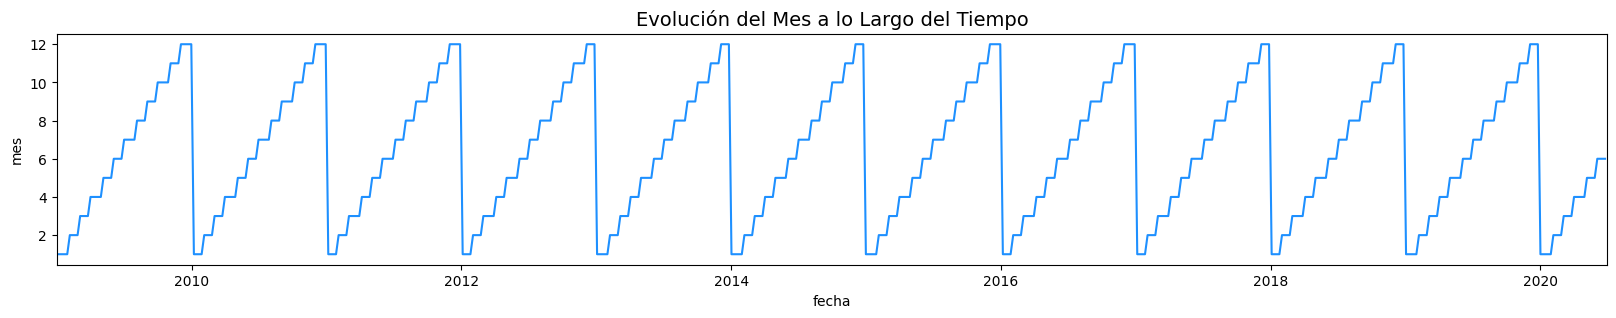

In [34]:
# Visualización de la evolución de la variable "mes" a lo largo del tiempo
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 3))
sns.lineplot(x=df['fecha'], y=df['mes'], color='dodgerblue')
ax.set_xlim([date(2009, 1, 1), date(2020, 6, 30)])
ax.set_title("Evolución del Mes a lo Largo del Tiempo", fontsize=14)
plt.show()

La gráfica muestra cómo el valor de la columna “mes” evoluciona con el tiempo. Puedes notar que:

- **Forma de sierra (o escalonada):**  
  Cada ciclo anual se ve como una línea que sube del valor 1 (enero) hasta 12 (diciembre), y luego da un “salto” de vuelta a 1 (enero del siguiente año).

- **Repetición anual:**  
  Cada bloque de subida (1 → 12) representa un año. Al finalizar diciembre (12), empieza el siguiente año en enero (1), provocando el salto que se ve en la gráfica.

- **Naturaleza cíclica:**  
  El mes es una variable cíclica, ya que una vez que termina diciembre, el siguiente valor vuelve a ser enero (1). Sin embargo, si lo interpretas como una variable numérica continua, verás esa “gran” diferencia (12 → 1).

**Interpretación clave:**  

- La línea escalonada te indica que, numéricamente, el mes pasa de 12 a 1 y que eso ocurre cada cambio de año.
- Muestra cómo, a lo largo del tiempo, la secuencia mensual se repite una y otra vez en el mismo patrón de 12 meses.
- Justamente, para que un modelo de aprendizaje automático “entienda” que diciembre y enero son consecutivos, se recurre a la codificación cíclica (seno y coseno), en lugar de tratar “mes” como un número puramente ordinal que va de 1 a 12. De esta forma, se respeta la continuidad temporal sin introducir grandes saltos entre diciembre y enero.

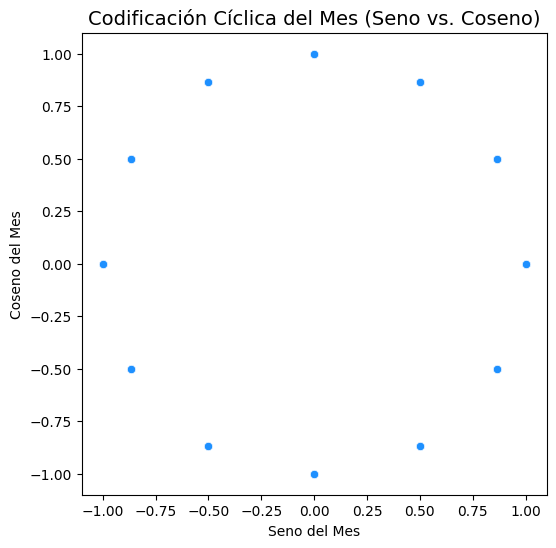

In [35]:
# Para codificar correctamente esta variable cíclica, se utilizan funciones trigonométricas.
# Se crea un nuevo feature que codifica el "mes" mediante sus valores seno y coseno.
# Esto permite que el modelo entienda que, por ejemplo, diciembre (12) y enero (1)
# son numéricamente cercanos (ya que forman parte de un ciclo continuo).

# Número de meses en un año
mes_en_anio = 12

# Crear las columnas codificadas: seno y coseno para el mes
df['mes_seno'] = np.sin(2 * np.pi * df['mes'] / mes_en_anio)
df['mes_coseno'] = np.cos(2 * np.pi * df['mes'] / mes_en_anio)

# Visualización del espacio codificado: los puntos deben formar un círculo
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
sns.scatterplot(x=df['mes_seno'], y=df['mes_coseno'], color='dodgerblue')
ax.set_title("Codificación Cíclica del Mes (Seno vs. Coseno)", fontsize=14)
ax.set_xlabel("Seno del Mes")
ax.set_ylabel("Coseno del Mes")
plt.show()

## Descomposición de Series de Tiempo

La descomposición de una serie de tiempo consiste en pensar la serie como la combinación de varios componentes que la conforman. Los componentes clásicos son:

- **Nivel:** Es el valor promedio de la serie.
- **Tendencia:** Representa el incremento o decremento a largo plazo de la serie.
- **Estacionalidad:** Es el patrón repetitivo a corto plazo (ciclos) que se observa en la serie.
- **Ruido:** Son las variaciones aleatorias o residuales que no se explican por los otros componentes.

Esta descomposición ofrece un modelo conceptual útil para analizar series de tiempo y entender mejor los problemas durante el análisis y pronóstico.

Todas las series tienen un nivel y ruido. Los componentes de tendencia y estacionalidad pueden o no estar presentes, dependiendo del comportamiento de la serie.
  
En este ejemplo se utiliza el modelo **aditivo** junto con la función `seasonal_decompose()` de la biblioteca *statsmodels*.

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Definir las columnas principales a descomponer
columnas_principales = [
    'lluvia', 'temperatura', 'volumen_drenaje',
    'hidrometría_río', 'profundidad_al_nivel_de_aguas_subterráneas'
]

# Realizar la descomposición de la serie para cada columna
# Se usa period=52 asumiendo que los datos son semanales, por ejemplo, para representar un año (52 semanas)
for columna in columnas_principales:
    # La función seasonal_decompose descompone la serie en tendencia y estacionalidad (en este ejemplo, se ignoran el nivel y el ruido)
    decomp = seasonal_decompose(df[columna], period=52, model='additive', extrapolate_trend='freq')
    df[f"{columna}_tendencia"] = decomp.trend
    df[f"{columna}_estacionalidad"] = decomp.seasonal

# Se pueden visualizar o analizar posteriormente los nuevos atributos creados:
df.head()

,fecha,profundidad_al_nivel_de_aguas_subterráneas,temperatura,volumen_drenaje,hidrometría_río,lluvia,profundidad_al_nivel_de_aguas_subterráneas_log,profundidad_al_nivel_de_aguas_subterráneas_diff_1,año,mes,...,lluvia_tendencia,lluvia_estacionalidad,temperatura_tendencia,temperatura_estacionalidad,volumen_drenaje_tendencia,volumen_drenaje_estacionalidad,hidrometría_río_tendencia,hidrometría_río_estacionalidad,profundidad_al_nivel_de_aguas_subterráneas_tendencia,profundidad_al_nivel_de_aguas_subterráneas_estacionalidad
0,2009-01-01,-31.048571,1.657143,-28164.918857,2.371429,0.000000,3.435553,0.000000,2009,1,...,0.806294,0.688948,15.329959,-9.739920,-32404.467037,1551.335303,2.164913,0.207547,-29.571657,-0.643767
1,2009-01-08,-30.784286,4.571429,-29755.789714,2.314286,0.285714,3.427004,0.264286,2009,1,...,0.809093,-0.728055,15.312814,-9.838787,-32374.371773,938.070633,2.167252,0.186527,-29.535110,-0.572078
2,2009-01-15,-30.420000,7.528571,-25463.190857,2.300000,0.028571,3.415100,0.364286,2009,1,...,0.811892,-0.717139,15.295668,-10.002955,-32344.276508,832.934327,2.169592,0.105423,-29.498564,-0.484281
3,2009-01-22,-30.018571,6.214286,-23854.422857,2.500000,0.585714,3.401816,0.401429,2009,1,...,0.814691,0.493481,15.278522,-9.973161,-32314.181244,518.836188,2.171931,0.131993,-29.462017,-0.417712
4,2009-01-29,-29.790000,5.771429,-25210.532571,2.500000,1.414286,3.394173,0.228571,2009,1,...,0.817490,-0.556499,15.261377,-10.246938,-32284.085980,238.454010,2.174270,0.152668,-29.425470,-0.362900


El siguiente gráfico ilustra visualmente la descomposición de una serie de tiempo en sus componentes principales. En este ejemplo, se muestra la descomposición de la variable **"volumen_drenaje"** en tres partes:

- **Serie Original:** Los datos tal como se registraron inicialmente.
- **Componente de Tendencia:** Muestra el comportamiento a largo plazo, eliminando las fluctuaciones estacionales.
- **Componente de Estacionalidad:** Resalta el patrón cíclico que se repite en cada período (en este caso, semanalmente, con un período de 52 semanas).

Esta visualización permite comprender mejor cómo se compone la serie y facilita la identificación de patrones y tendencias, lo cual es fundamental para un análisis y pronóstico adecuados.

A continuación, se muestra el código para generar este gráfico usando Plotly:

In [37]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Seleccionar la variable a ilustrar (por ejemplo, "volumen_drenaje")
variable = "volumen_drenaje"

# Crear una figura con 3 filas y 1 columna, compartiendo el eje x
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        "Serie Original",
        "Componente de Tendencia",
        "Componente de Estacionalidad"
    ],
    shared_xaxes=True,
    vertical_spacing=0.08
)

# Subplot 1: Serie Original
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df[variable],
        mode="lines",
        name="Original",
        line=dict(color='dodgerblue')
    ),
    row=1, col=1
)

# Subplot 2: Componente de Tendencia
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df[f"{variable}_tendencia"],
        mode="lines",
        name="Tendencia",
        line=dict(color='firebrick')
    ),
    row=2, col=1
)

# Subplot 3: Componente de Estacionalidad
fig.add_trace(
    go.Scatter(
        x=df['fecha'],
        y=df[f"{variable}_estacionalidad"],
        mode="lines",
        name="Estacionalidad",
        line=dict(color='orange')
    ),
    row=3, col=1
)

# Configurar el layout general de la figura
fig.update_layout(
    title_text=f"Descomposición de la Serie: {variable.capitalize()}",
    height=800,
    width=1000,
    showlegend=True,
    title_x=0.5
)

fig.show()


## Retrasos (Lag)

La idea detrás de la creación de variables de retraso (lags) es obtener versiones desplazadas en el tiempo de la componente estacional de cada variable principal. Esto permite comparar y analizar cómo la información pasada y futura (en relación al punto actual) se correlaciona con el comportamiento actual de la serie.

- **Definición:**  
  Un "lag" (retraso) es simplemente el valor de una variable en un momento anterior o futuro, desplazado respecto al tiempo actual. Por ejemplo, en una serie diaria, un lag de 1 día es el valor del día anterior.

- **Uso práctico:**  
  Al crear variables retrasadas, podemos:
  - **Comparar:** Determinar la relación entre el valor actual y sus valores pasados (o futuros).  
  - **Modelar:** Estas relaciones son muy útiles para detectar patrones temporales, lo que puede mejorar la capacidad predictiva de un modelo de series de tiempo (como ARIMA o modelos de machine learning).

Por ejemplo, la variable "mes" o la componente estacional de otra variable, cambia de forma cíclica. Con un desfase o "lag", podemos ver si hay una correlación entre el valor actual y el valor de la serie un mes, dos meses, o tres meses antes o después. Esta información puede ser muy útil para la modelización y el pronóstico, porque nos ayuda a detectar patrones temporales y dependencias en la serie.

Se define que aproximadamente un mes equivale a 4 semanas, y se crean nuevos atributos para cada variable en `columnas_principales` (por ejemplo, 'lluvia', 'temperatura', 'volumen_drenaje', 'hidrometría_río', 'profundidad_al_nivel_de_aguas_subterráneas') a partir de la componente estacional ya descompuesta, que en nuestro caso se guarda con el sufijo `_estacionalidad`.

En este ejemplo se crean cinco variables nuevas con distintos retrasos (dos negativos para observar valores futuros y tres positivos para ver valores pasados), donde "m" indica un desfase equivalente a un mes (4 semanas).

In [38]:
# Definir cuántas semanas (aproximadamente) conforman un mes
semanas_en_mes = 4

# 'columnas_principales' es una lista que contiene las variables de interés, por ejemplo:
columnas_principales = [
    'lluvia',
    'temperatura',
    'volumen_drenaje',
    'hidrometría_río',
    'profundidad_al_nivel_de_aguas_subterráneas'
]

# Para cada variable principal, generar nuevas columnas con desplazamientos en la componente estacionalidad
for columna in columnas_principales:
    # Desplazamientos hacia adelante (valores futuros)
    df[f'{columna}_estacionalidad_retraso_neg_2m'] = df[f'{columna}_estacionalidad'].shift(-2 * semanas_en_mes)
    df[f'{columna}_estacionalidad_retraso_neg_1m'] = df[f'{columna}_estacionalidad'].shift(-1 * semanas_en_mes)

    # Desplazamientos hacia atrás (valores pasados)
    df[f'{columna}_estacionalidad_retraso_1m'] = df[f'{columna}_estacionalidad'].shift(1 * semanas_en_mes)
    df[f'{columna}_estacionalidad_retraso_2m'] = df[f'{columna}_estacionalidad'].shift(2 * semanas_en_mes)
    df[f'{columna}_estacionalidad_retraso_3m'] = df[f'{columna}_estacionalidad'].shift(3 * semanas_en_mes)

## Análisis Exploratorio de Datos

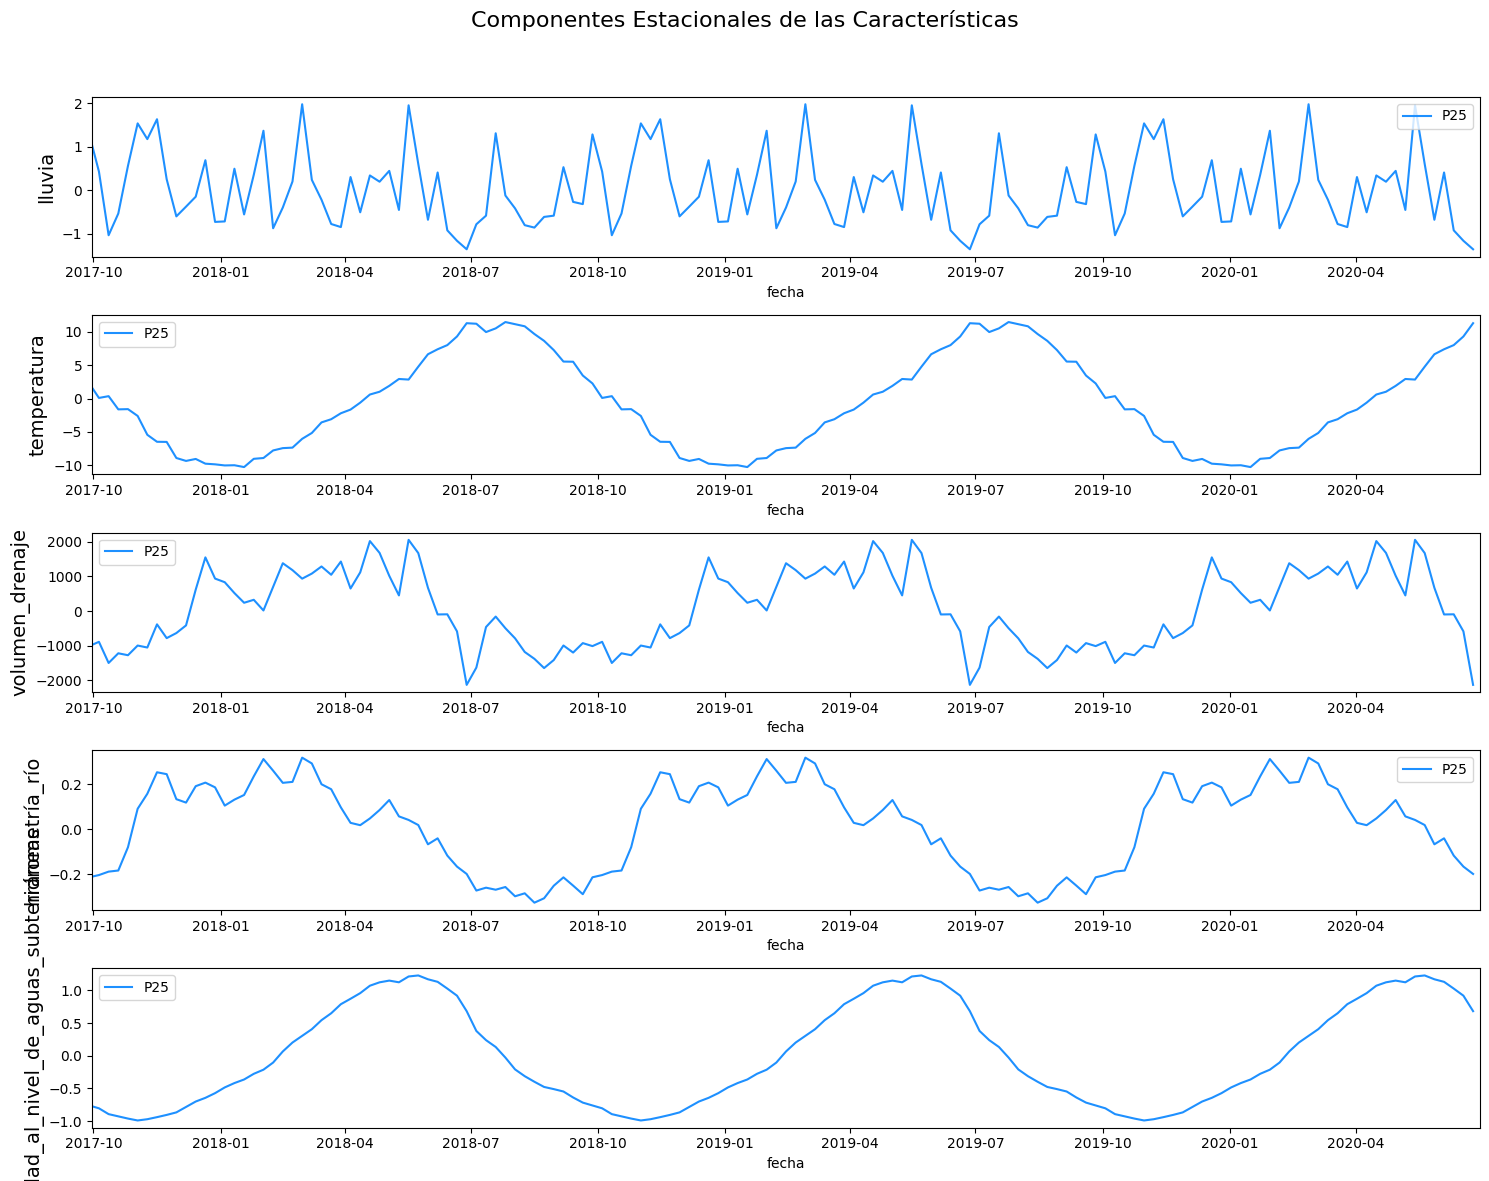

In [40]:

# Lista de columnas principales (en español) y sus componentes estacionales
core_columns = [
    'lluvia',
    'temperatura',
    'volumen_drenaje',
    'hidrometría_río',
    'profundidad_al_nivel_de_aguas_subterráneas'
]

# Crear la figura con 5 filas y 1 columna
f, ax = plt.subplots(nrows=5, ncols=1, figsize=(15, 12))
f.suptitle('Componentes Estacionales de las Características', fontsize=16)

# Ajustar el layout para evitar que el título general se sobreponga con los subplots
plt.subplots_adjust(top=0.92)

# Iterar sobre cada columna para graficar su componente estacional
for i, columna in enumerate(core_columns):
    sns.lineplot(x=df['fecha'], y=df[columna + '_estacionalidad'], ax=ax[i], color='dodgerblue', label='P25')
    ax[i].set_ylabel(columna, fontsize=14)
    ax[i].set_xlim([date(2017, 9, 30), date(2020, 6, 30)])
    # Es opcional establecer un título individual para cada subplot, en este caso lo dejamos vacío para evitar sobreposición
    ax[i].set_title("")

# Ajustar el layout final, dejando espacio suficiente para el título general
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [43]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from datetime import date

# Lista de columnas principales (ya definidas previamente)
core_columns = [
    'lluvia',
    'temperatura',
    'volumen_drenaje',
    'hidrometría_río',
    'profundidad_al_nivel_de_aguas_subterráneas'
]

# Crear una figura con 5 filas y 1 columna, compartiendo el eje x
fig = make_subplots(
    rows=5, cols=1,
    shared_xaxes=True,
    subplot_titles=[f"Componente Estacional de {columna}" for columna in core_columns]
)

# Recorrer cada columna para agregar la traza correspondiente
for i, columna in enumerate(core_columns):
    fig.add_trace(
        go.Scatter(
            x=df['fecha'],
            y=df[f"{columna}_estacionalidad"],
            mode="lines",
            line=dict(color='dodgerblue'),
            name=columna
        ),
        row=i+1, col=1  # i+1 porque Plotly comienza a indexar las filas en 1
    )
    # Configurar el eje y para cada subplot
    fig.update_yaxes(title_text=columna, row=i+1, col=1)
    # Establecer los límites del eje x para cada subplot
    fig.update_xaxes(range=[date(2017, 9, 30), date(2020, 6, 30)], row=i+1, col=1)

# Configurar el layout general de la figura
fig.update_layout(
    height=1200,
    width=900,
    title_text='Componentes Estacionales de las Características',
    title_font_size=16,
    showlegend=False
)

fig.show()


### Conclusiones sobre las Componentes Estacionales (en español)

A partir de la gráfica de componentes estacionales para cada variable, se pueden extraer las siguientes observaciones:

- **Profundidad al Nivel de Aguas Subterráneas:**  
  - Alcanza su valor **máximo** aproximadamente en **mayo/junio**.  
  - Alcanza su valor **mínimo** alrededor de **noviembre**.  
  - Esto sugiere que la recarga del acuífero (por lluvias y otros factores) es mayor durante la primavera, mientras que en otoño la profundidad tiende a aumentar (disminuyendo el nivel freático).

- **Temperatura:**  
  - Llega a su punto **más alto** en **agosto**.  
  - Su valor **más bajo** se observa en **enero**.  
  - Refleja un patrón estacional claro, con veranos cálidos e inviernos fríos.

- **Volumen de Drenaje:**  
  - Presenta su **mínimo** aproximado en **julio**.  
  - Si bien la gráfica no muestra explícitamente el pico máximo, el mínimo en julio podría asociarse a una menor demanda de drenaje o a condiciones climáticas más secas.

- **Hidrometría del Río:**  
  - Su **máximo** se concentra entre **febrero y marzo**.  
  - Su **mínimo** ocurre cerca de **septiembre**.  
  - Esto apunta a que los caudales del río son mayores a finales del invierno, mientras que disminuyen considerablemente en el periodo de final de verano o inicio de otoño.

**Interpretación General:**  
Estos patrones estacionales ofrecen una visión clara de cómo cada variable fluctúa a lo largo del año. Por ejemplo, la profundidad al nivel de aguas subterráneas suele aumentar en época de recarga (primavera), la temperatura se comporta como cabría esperar en un clima templado (picos en verano y valles en invierno), y la hidrometría del río exhibe sus valores más altos en la época de deshielo o lluvia invernal. Estas observaciones son útiles para la **planificación hídrica**, la **predicción de demanda** o la **toma de decisiones** en diferentes sectores (agrícola, industrial, doméstico, etc.).


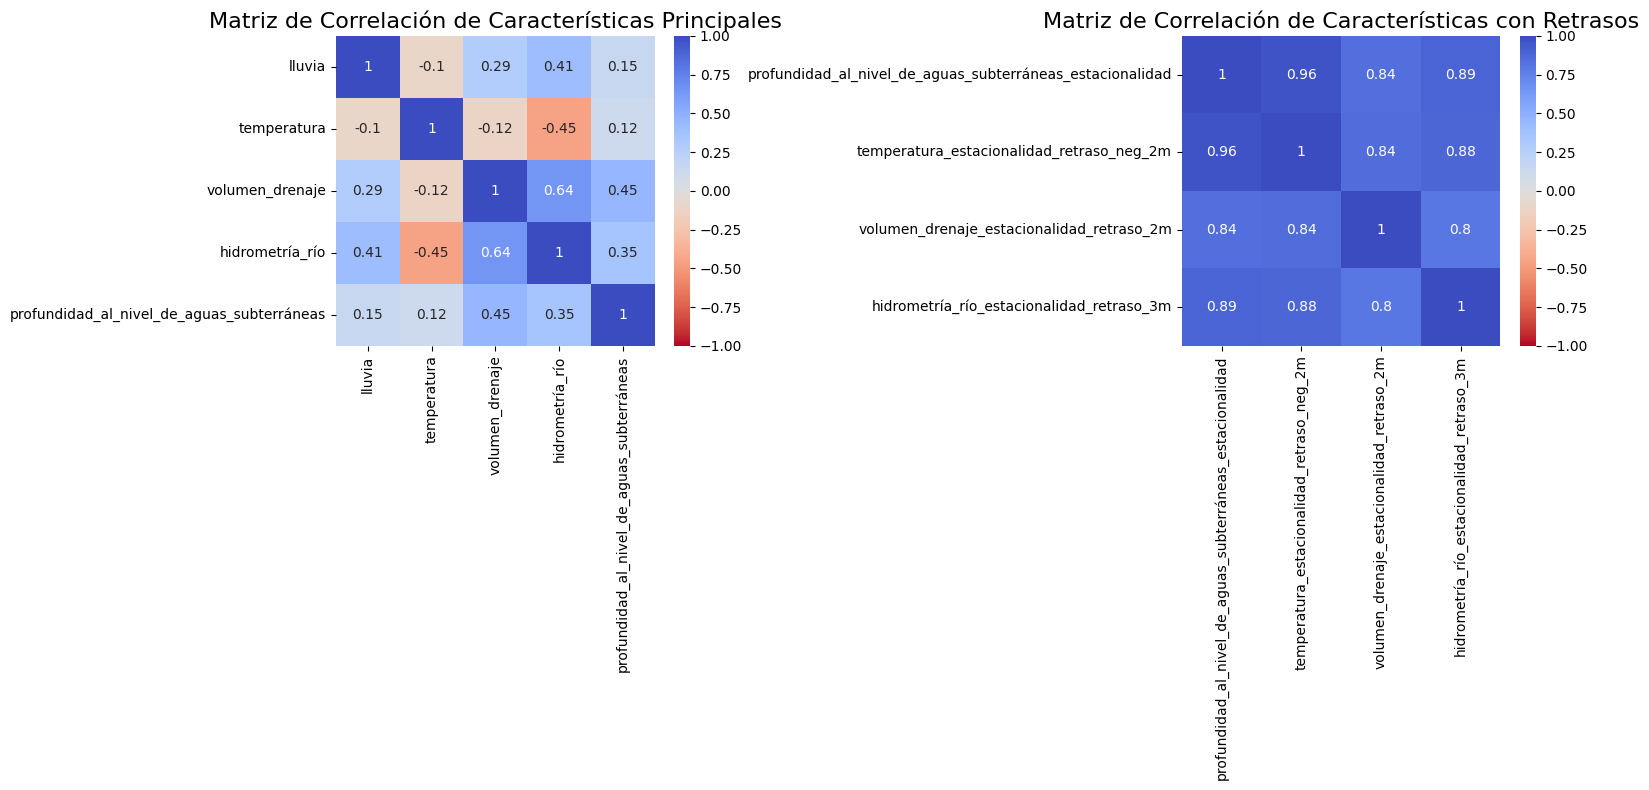

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# Definir las columnas principales en español
core_columns = [
    'lluvia',
    'temperatura',
    'volumen_drenaje',
    'hidrometría_río',
    'profundidad_al_nivel_de_aguas_subterráneas'
]

# Crear la figura con 1 fila y 2 columnas
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

# Calcular la matriz de correlación para las características principales
corrmat = df[core_columns].corr()

# Graficar el heatmap de la matriz de correlación de las variables principales
sns.heatmap(corrmat, annot=True, vmin=-1, vmax=1, cmap='coolwarm_r', ax=ax[0])
ax[0].set_title('Matriz de Correlación de Características Principales', fontsize=16)

# Definir las columnas desplazadas (lagged) en español;
# se asume que previamente se han creado las columnas de la componente estacionalidad con lag.
shifted_cols = [
    'profundidad_al_nivel_de_aguas_subterráneas_estacionalidad',
    'temperatura_estacionalidad_retraso_neg_2m',  # Componentes en el futuro (desplazamiento negativo)
    'volumen_drenaje_estacionalidad_retraso_2m',    # Valor pasado (desplazamiento positivo de 2 meses)
    'hidrometría_río_estacionalidad_retraso_3m'      # Valor pasado (desplazamiento positivo de 3 meses)
]

# Calcular la matriz de correlación para las características con retrasos
corrmat_shifted = df[shifted_cols].corr()
sns.heatmap(corrmat_shifted, annot=True, vmin=-1, vmax=1, cmap='coolwarm_r', ax=ax[1])
ax[1].set_title('Matriz de Correlación de Características con Retrasos', fontsize=16)

plt.tight_layout()
plt.show()


### ¿Por qué las variables desplazadas (lagged) pueden mostrar mayor correlación?

En series de tiempo, no todas las variables ocurren y afectan a otras en el mismo instante. Con frecuencia existe un **desfase temporal** entre una causa y su efecto. Por ejemplo, la lluvia de hoy puede tardar días o semanas en infiltrarse y modificar la profundidad del acuífero o el caudal de un río. De ahí que, al alinear los datos con un **lag** (es decir, retrasar una variable en el tiempo o adelantarla), puedes encontrar una correlación más alta que con los valores sin desplazar.

**Interpretación de la Matriz de Correlación con Retrasos:**

1. **Desfase Natural o Físico en el Fenómeno:**  
   - La respuesta de cierta variable (p. ej., profundidad al nivel de aguas subterráneas) puede manifestarse tiempo después de que suceda un evento (p. ej., lluvia intensa).  
   - Al introducir retrasos (por ejemplo, 1 o 2 meses), es posible alinear mejor el momento en el que se registra el efecto de una variable sobre otra.

2. **Mayor Correlación:**  
   - Si observas que la **matriz de correlación con lag** muestra valores de correlación más altos, eso significa que los datos se ajustan mejor temporalmente a la realidad del proceso.  
   - Por ejemplo, puede que en la misma semana que llueve no varíe mucho la profundidad de las aguas subterráneas, pero sí cambie significativamente dos o tres semanas más tarde.

3. **Conclusión para el Análisis:**  
   - Este resultado indica que, para modelar o predecir ciertos fenómenos, es crucial considerar estos **desplazamientos temporales**.  
   - Si tu objetivo es pronosticar la profundidad al nivel de aguas subterráneas, seguramente necesites introducir las variables relacionadas con la lluvia, el caudal del río, etc., con el **lag** adecuado que refleje el tiempo que tarda en manifestarse el efecto de dichas variables.

4. **Ejemplo Práctico:**  
   - Una correlación alta entre la **temperatura_estacionalidad_retraso_neg_2m** y la **profundidad_al_nivel_de_aguas_subterráneas_estacionalidad** podría significar que la temperatura de hace dos meses está fuertemente relacionada con el nivel de agua actual.  
   - Esto podría explicarse por procesos como la evapotranspiración y la infiltración, que no se dan de manera instantánea.

**En resumen**, la observación de que “las características con retrasos muestran mayor correlación que las originales” sugiere que existen dependencias temporales claras entre las variables, y que dichas dependencias se manifiestan al cabo de cierto retardo. Esto es un **indicador valioso** para construir modelos predictivos más precisos y realistas, pues incorporar los lags adecuados tiende a mejorar la capacidad de explicar (o predecir) los fenómenos.


## Análisis de Autocorrelación

El análisis de autocorrelación es un método para examinar cómo se relacionan los valores actuales de una serie de tiempo con sus propios valores pasados. Esto es muy importante para detectar patrones y dependencias temporales.

### Conceptos Clave:

- **Función de Autocorrelación (ACF):**  
  Mide la correlación entre un valor actual y valores anteriores en la serie para diferentes desfases (lags).  
  *Ejemplo sencillo:* Si la correlación es alta para el desfase 3, significa que el valor actual está fuertemente relacionado con el valor de hace 3 períodos.

- **Función de Autocorrelación Parcial (PACF):**  
  Muestra la relación directa entre un valor actual y uno pasado en particular, eliminando la influencia de los valores intermedios.  
  *Ejemplo sencillo:* Si la correlación parcial para un desfase de 2 es alta, indica que el valor actual tiene una relación fuerte con el de hace 2 períodos, sin contar la influencia de otros lags.

### ¿Para qué sirve?

- **Determinar los parámetros de un modelo ARIMA:**  
  - El gráfico de **ACF** ayuda a identificar cuántos términos de media móvil (MA) incluir en el modelo.
  - El gráfico de **PACF** ayuda a decidir cuántos términos autoregresivos (AR) se deben usar.
- **Detectar patrones estacionales:**  
  Se utiliza para ver si existen dependencias o patrones que se repiten a intervalos regulares en la serie.

En resumen, estos gráficos son herramientas fundamentales para entender la estructura temporal de la serie y para la selección del modelo más adecuado para pronosticarla.

---

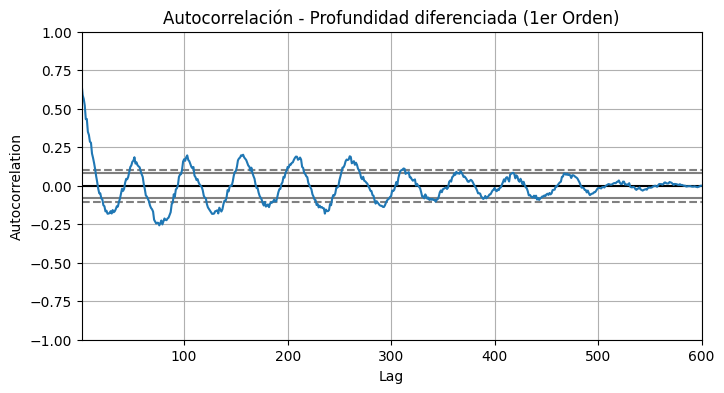

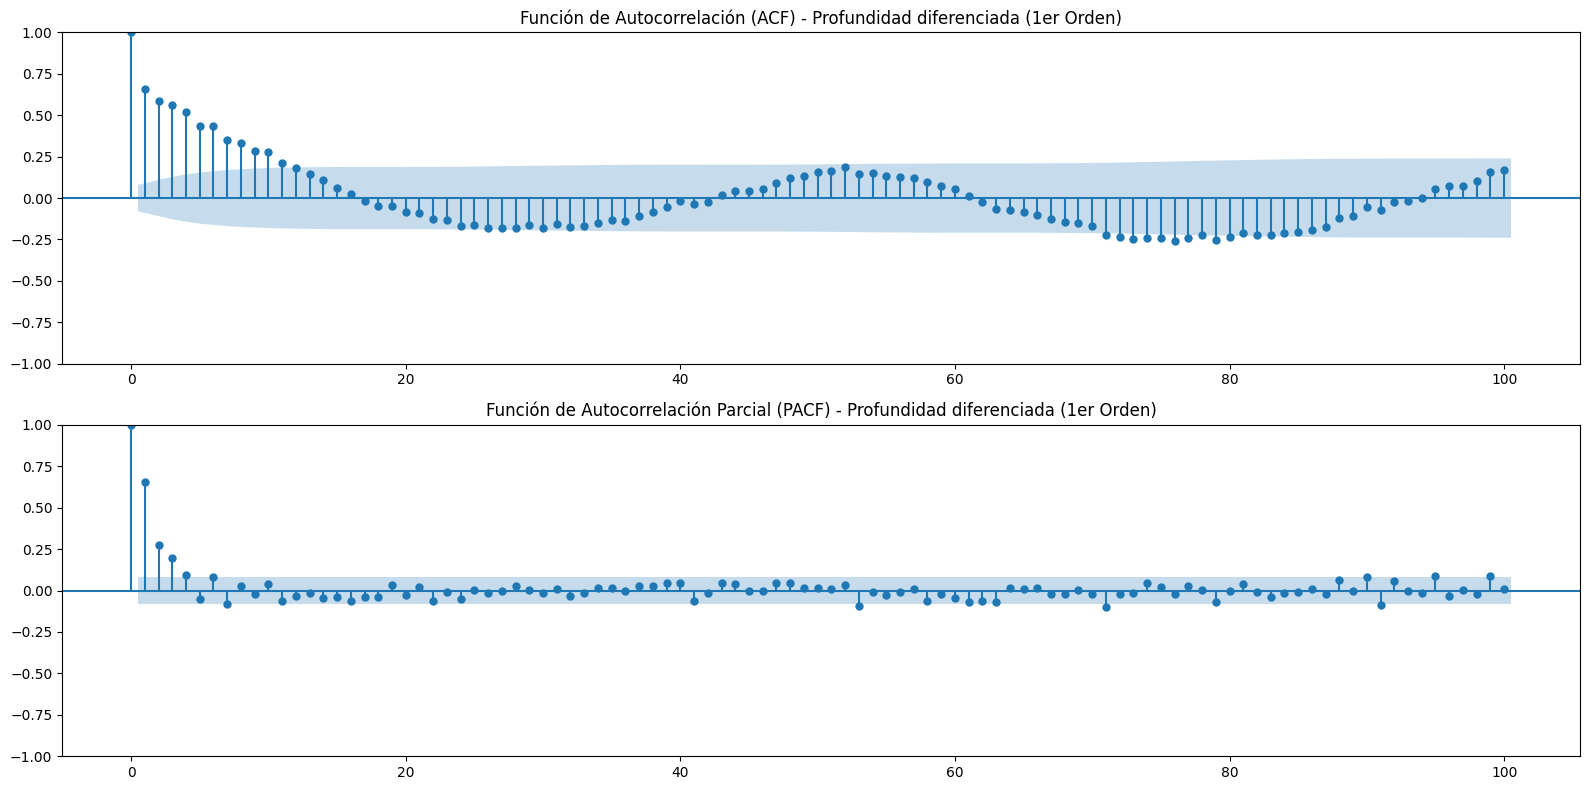

In [45]:
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ejemplo 1: Gráfico de autocorrelación simple usando la función de pandas
plt.figure(figsize=(8, 4))
autocorrelation_plot(df['profundidad_al_nivel_de_aguas_subterráneas_diff_1'])
plt.title("Autocorrelación - Profundidad diferenciada (1er Orden)")
plt.show()

# Ejemplo 2: Gráficos de ACF y PACF usando statsmodels
f, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 8))

plot_acf(df['profundidad_al_nivel_de_aguas_subterráneas_diff_1'], lags=100, ax=ax[0])
ax[0].set_title("Función de Autocorrelación (ACF) - Profundidad diferenciada (1er Orden)")

plot_pacf(df['profundidad_al_nivel_de_aguas_subterráneas_diff_1'], lags=100, ax=ax[1])
ax[1].set_title("Función de Autocorrelación Parcial (PACF) - Profundidad diferenciada (1er Orden)")

plt.tight_layout()
plt.show()

La figura muestra **dos gráficos**:

1. **Función de Autocorrelación (ACF)** de la serie diferenciada (arriba)  
2. **Función de Autocorrelación Parcial (PACF)** de la serie diferenciada (abajo)

### ¿Qué significan los picos en cada gráfico?

1. **ACF (Gráfico Superior):**  
   - Se observa que el valor de autocorrelación arranca siendo positivo (en torno a \~0.3) para el primer lag y luego decae gradualmente, incluso volviéndose negativo, antes de aproximarse a 0 a medida que aumentan los lags.  
   - Esta lenta disminución sugiere que hay cierta “memoria” en la serie diferenciada, pero no se mantiene una autocorrelación significativa a lo largo de muchos lags.  
   - **Interpretación en términos MA:** Un decaimiento relativamente rápido puede indicar que no es necesario incluir muchos términos de media móvil (\(q\)) al modelar con ARIMA, aunque se podría explorar uno o dos términos MA si los picos iniciales están por fuera de la banda de significancia (las áreas sombreadas).

2. **PACF (Gráfico Inferior):**  
   - El primer lag presenta un pico notablemente alto (por encima de la banda de confianza), lo que indica una **fuerte influencia** del valor inmediato anterior.  
   - A partir del segundo lag, las barras caen muy cerca o dentro de la banda de significancia, lo que significa que la contribución de lags más lejanos es pequeña o nula.  
   - **Interpretación en términos AR:** Un pico significativo solo en el primer lag sugiere que se podría incluir **1 término AR** (\(p = 1\)) en un modelo ARIMA para capturar la dependencia autoregresiva.

### Conclusión para un Modelo ARIMA

- **Orden de Diferenciación (d):** Ya hemos diferenciado la serie 1 vez, por lo que \(d = 1\).  
- **Orden Autorregresivo (p):** El PACF indica un pico alto en lag 1 y poco más allá, lo que sugiere \(p = 1\).  
- **Orden de Media Móvil (q):** El ACF no muestra una cola prolongada o picos claros que se mantengan fuera de la banda a lags más altos, por lo que \(q\) podría ser 0 o 1, dependiendo de si vemos alguna barra inicial fuera de la banda de confianza.

En la práctica, estos gráficos se usan como guía. Lo siguiente sería **probar modelos ARIMA(p=1, d=1, q=0) o ARIMA(p=1, d=1, q=1)** y comparar sus métricas de desempeño (AIC, BIC, RMSE, etc.) para determinar cuál describe mejor la serie de tiempo diferenciada.


## Entrenamiento y validación

In [52]:
# Dividir el DataFrame en datos de entrenamiento y validación (85% entrenamiento, 15% validación)
train_size = int(0.85 * len(df))
test_size = len(df) - train_size

# Crear un DataFrame univariante para modelar la "profundidad al nivel de aguas subterráneas" a lo largo del tiempo.
# Se toma la columna 'fecha' y 'profundidad_al_nivel_de_aguas_subterráneas' y se renombran a 'ds' y 'y'
# Esto es útil para ciertos modelos (como Prophet), pero también sirve para ajustar ARIMA.
univariate_df = df[['fecha', 'profundidad_al_nivel_de_aguas_subterráneas']].copy()
univariate_df.columns = ['ds', 'y']

# Dividir el DataFrame univariante en entrenamiento y validación
train = univariate_df.iloc[:train_size, :]

# También se separan las columnas de fecha y valor en conjuntos de entrenamiento y validación
x_train = pd.DataFrame(univariate_df.iloc[:train_size, 0])
y_train = pd.DataFrame(univariate_df.iloc[:train_size, 1])
x_valid = pd.DataFrame(univariate_df.iloc[train_size:, 0])
y_valid = pd.DataFrame(univariate_df.iloc[train_size:, 1])

# Imprimir la cantidad de registros en entrenamiento y validación para confirmar la división
print("Datos de entrenamiento:", len(train), "Datos de validación:", len(x_valid))


Datos de entrenamiento: 510 Datos de validación: 90


## ARIMA

El modelo ARIMA (Auto-Regressive Integrated Moving Average) es un modelo estadístico que se utiliza para analizar y pronosticar series de tiempo. Este modelo se basa en tres componentes principales:

1. **Filtro Autorregresivo (AR):**  
   - Representa la dependencia a largo plazo, en la que el valor actual de la serie se explica por valores pasados

2. **Filtro de Integración (I):**  
   - Se utiliza para convertir la serie no estacionaria en estacionaria mediante diferenciación.  
   - El número de diferencias requeridas se denota por \(d\).

3. **Filtro de Media Móvil (MA):**  
   - Modela el efecto a corto plazo mediante el error de predicción de períodos anteriores.

El modelo ARIMA se denota como **ARIMA(p, d, q)**, donde:
- \(p\) es el número de lags (retrasos) en la parte autorregresiva. (Se puede determinar observando el gráfico de PACF).
- \(d\) es el número de diferenciaciones necesarias para estacionarizar la serie.
- \(q\) es el número de términos de media móvil. (Se puede determinar observando el gráfico de ACF).

### Pasos para analizar y ajustar un modelo ARIMA:

1. **Verificar la estacionariedad:**  
   Si la serie de tiempo tiene tendencia o estacionalidad, primero debe ser transformada (mediante diferenciación) para hacerla estacionaria.

2. **Diferenciación:**  
   Se toma la primera diferencia, o más si es necesario, hasta que la serie se vuelve estacionaria. También se debe considerar la diferenciación estacional si corresponde.

3. **Dividir en muestra de validación:**  
   Se separa un subconjunto de la serie (train y test) para evaluar la precisión del modelo.

4. **Selección de términos AR y MA:**  
   Se utilizan los gráficos ACF y PACF para identificar la cantidad de términos a incluir en la parte autoregresiva (AR) y en la media móvil (MA).

5. **Construir el modelo:**  
   Se ajusta el modelo ARIMA usando los parámetros elegidos (p, d, q) y se define cuántos períodos se desea pronosticar.

6. **Validar el modelo:**  
   Se comparan los valores pronosticados con los valores reales de la muestra de validación y se calculan métricas de error como MAE y RMSE.

---

In [54]:
from statsmodels.tsa.arima.model import ARIMA  # Importa el modelo ARIMA (nota: en versiones antiguas se usaba fbprophet)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# Ajustar el modelo ARIMA (p, d, q) - en este ejemplo, ARIMA(1,1,1)
modelo_arima = ARIMA(y_train, order=(1, 1, 1))
modelo_arima_fit = modelo_arima.fit()

# Realizar la predicción para los próximos test_size períodos (por ejemplo, 90 períodos)
# En la versión actual, la función forecast devuelve solo las predicciones
y_pred = modelo_arima_fit.forecast(steps=90)

# Calcular las métricas de error
mae = mean_absolute_error(y_valid, y_pred)
rmse = math.sqrt(mean_squared_error(y_valid, y_pred))

print("RMSE:", rmse)

RMSE: 1.402615843711107


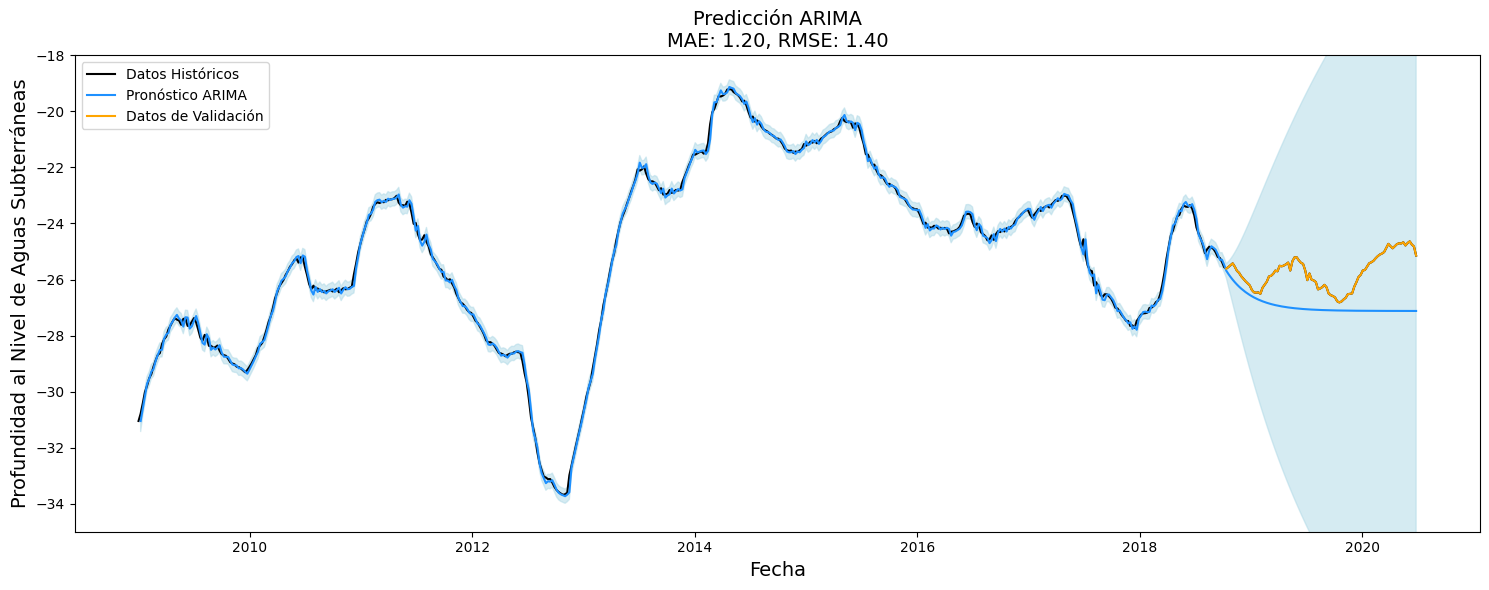

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Usar get_prediction en lugar de plot_predict (método obsoleto en la versión actual de statsmodels)
# Se realiza la predicción desde el índice 1 hasta el final de la serie
pred = modelo_arima_fit.get_prediction(start=1, end=len(univariate_df)-1)
predicted_values = pred.predicted_mean
conf_int = pred.conf_int()

# Graficar la serie histórica, el pronóstico y los intervalos de confianza
plt.figure(figsize=(15, 6))

# Graficar la serie histórica (todos los datos)
plt.plot(univariate_df['ds'], univariate_df['y'], label='Datos Históricos', color='black')

# Graficar el pronóstico obtenido, desde el índice 1 hasta el final
plt.plot(univariate_df['ds'].iloc[1:], predicted_values, label='Pronóstico ARIMA', color='dodgerblue')

# Graficar los intervalos de confianza (relleno de color lightblue)
plt.fill_between(univariate_df['ds'].iloc[1:],
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='lightblue', alpha=0.5)

# Graficar la serie de validación (datos reales)
plt.plot(x_valid['ds'], y_valid['y'], label='Datos de Validación', color='orange')

# Configurar título y etiquetas
plt.title(f'Predicción ARIMA\nMAE: {mae:.2f}, RMSE: {rmse:.2f}', fontsize=14)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Profundidad al Nivel de Aguas Subterráneas', fontsize=14)

# Establecer límites en el eje y para enfocar la visualización
plt.ylim(-35, -18)

plt.legend()
plt.tight_layout()
plt.show()


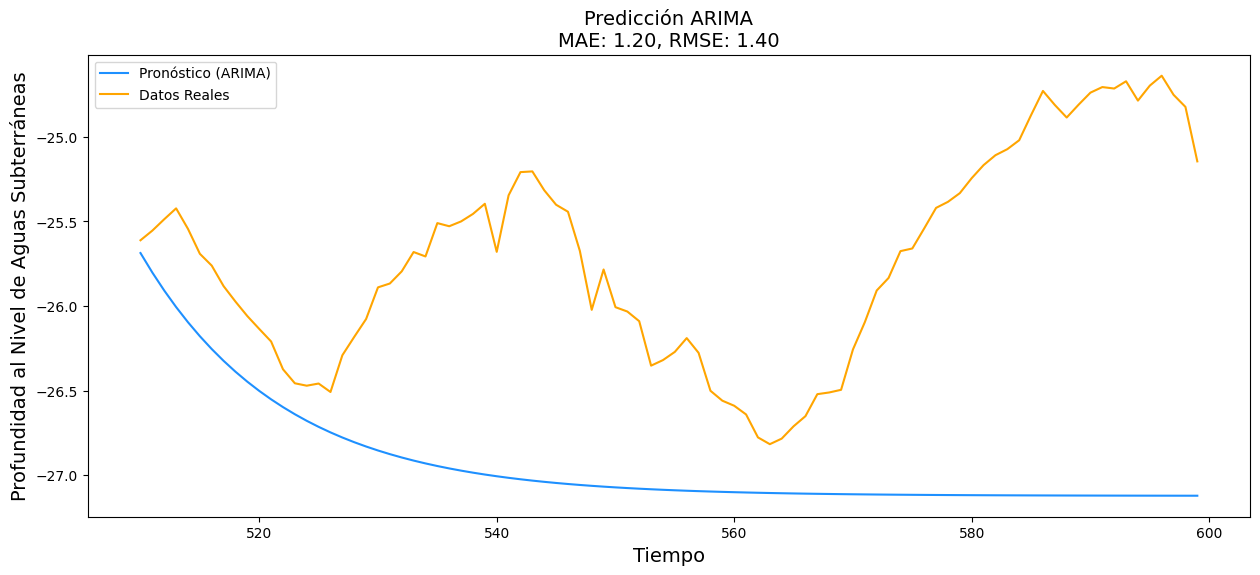

In [55]:
# Graficar los resultados de la predicción versus los datos reales
f, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_pred, label='Pronóstico (ARIMA)', color='dodgerblue')
ax.plot(y_valid, label='Datos Reales', color='orange')
ax.set_title(f'Predicción ARIMA\nMAE: {mae:.2f}, RMSE: {rmse:.2f}', fontsize=14)
ax.set_xlabel('Tiempo', fontsize=14)
ax.set_ylabel('Profundidad al Nivel de Aguas Subterráneas', fontsize=14)
ax.legend()

plt.show()

## SARIMAX

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Paso 1: Preparar el DataFrame Multivariante ---
# Seleccionamos las columnas relevantes:
# - 'fecha': fecha de registro.
# - Variables exógenas: 'lluvia', 'temperatura', 'volumen_drenaje', 'hidrometría_río'.
# - Variable objetivo: 'profundidad_al_nivel_de_aguas_subterráneas'.
multivar_df = df[['fecha', 'lluvia', 'temperatura', 'volumen_drenaje', 'hidrometría_río', 'profundidad_al_nivel_de_aguas_subterráneas']].copy()

# Renombramos las columnas para estandarizar:
# 'fecha' -> 'ds' (timestamp), y 'profundidad_al_nivel_de_aguas_subterráneas' -> 'y' (variable a pronosticar)
multivar_df.rename(columns={'fecha': 'ds',
                            'profundidad_al_nivel_de_aguas_subterráneas': 'y'}, inplace=True)

# --- Paso 2: Dividir en Datos de Entrenamiento y Validación ---
train_size = int(0.85 * len(multivar_df))
test_size = len(multivar_df) - train_size

train = multivar_df.iloc[:train_size].copy()
test  = multivar_df.iloc[train_size:].copy()

# Separar la variable objetivo y las variables exógenas
y_train = train['y']
y_test = test['y']
exog_cols = ['lluvia', 'temperatura', 'volumen_drenaje', 'hidrometría_río']
exog_train = train[exog_cols]
exog_test = test[exog_cols]

# --- Paso 3: Ajustar el Modelo SARIMAX (ARIMAX) ---
# En este ejemplo, usaremos un modelo SARIMAX sin componente estacional con parámetros (1,1,1).
# Esto corresponde a un modelo ARIMA con variable exógena (ARIMAX).
modelo_sarimax = SARIMAX(y_train, order=(1, 1, 1), exog=exog_train)
modelo_sarimax_fit = modelo_sarimax.fit(disp=False)

# --- Paso 4: Realizar la Predicción ---
# Predecir para el conjunto de validación, utilizando también las variables exógenas correspondientes.
predicciones = modelo_sarimax_fit.get_forecast(steps=test_size, exog=exog_test)
y_pred = predicciones.predicted_mean
intervalos_confianza = predicciones.conf_int()

# --- Paso 5: Calcular las Métricas de Error ---
mae = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 1.13, RMSE: 1.34


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



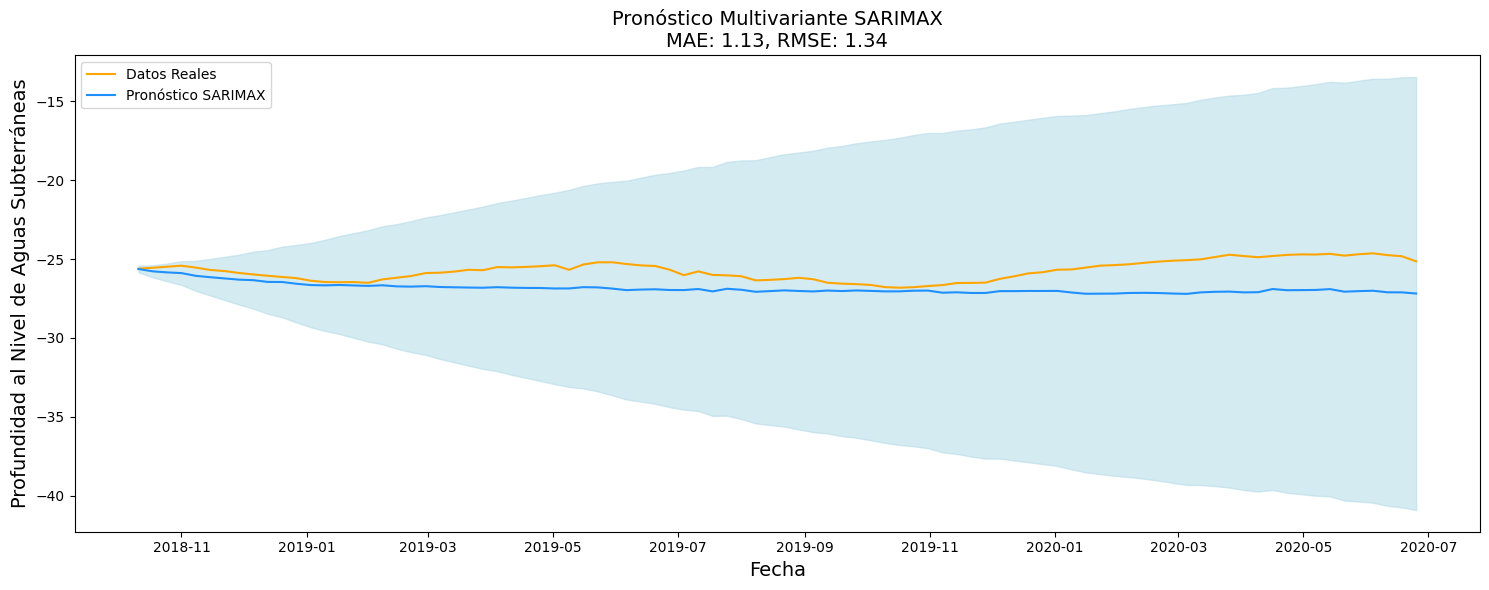

In [60]:
# --- Paso 6: Graficar los Resultados ---
plt.figure(figsize=(15, 6))
# Graficar los datos reales (validación)
plt.plot(test['ds'], y_test, label='Datos Reales', color='orange')
# Graficar el pronóstico del modelo
plt.plot(test['ds'], y_pred, label='Pronóstico SARIMAX', color='dodgerblue')
# Mostrar los intervalos de confianza
plt.fill_between(test['ds'],
                 intervalos_confianza.iloc[:, 0],
                 intervalos_confianza.iloc[:, 1],
                 color='lightblue', alpha=0.5)

plt.title(f'Pronóstico Multivariante SARIMAX\nMAE: {mae:.2f}, RMSE: {rmse:.2f}', fontsize=14)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Profundidad al Nivel de Aguas Subterráneas', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## LSTM

In [61]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# Asumimos que "univariate_df" ya contiene la serie univariante con las columnas ['ds', 'y']
# 'ds' contiene las fechas y 'y' la variable "profundidad al nivel de aguas subterráneas".

# Paso 1: Seleccionar la variable a modelar y convertirla a un array numpy
datos = univariate_df.filter(['y'])
dataset = datos.values  # Convertir el DataFrame a un array de numpy

# Paso 2: Normalizar los datos
# Se utiliza MinMaxScaler para escalar los valores al rango (-1, 0)
scaler = MinMaxScaler(feature_range=(-1, 0))
scaled_data = scaler.fit_transform(dataset)
print("Primeros 10 valores escalados:\n", scaled_data[:10])

# Paso 3: Definir la ventana móvil (look_back)
# 'look_back' determina cuántos períodos pasados se usarán para predecir el siguiente.
look_back = 52

# Paso 4: Dividir los datos normalizados en entrenamiento y prueba
# Se utiliza el tamaño de entrenamiento definido previamente (train_size) y se resta 'look_back'
# para asegurarnos de que haya suficientes datos para formar las ventanas.
train = scaled_data[:train_size - look_back, :]
test = scaled_data[train_size - look_back:, :]

# Paso 5: Función para convertir un array de valores en una matriz de datos
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(look_back, len(dataset)):
        # Tomamos "look_back" valores anteriores como características de entrada
        a = dataset[i - look_back:i, 0]
        X.append(a)
        # El siguiente valor en la serie es la variable objetivo
        Y.append(dataset[i, 0])
    return np.array(X), np.array(Y)

x_train, y_train = create_dataset(train, look_back)
x_test, y_test = create_dataset(test, look_back)

# Paso 6: Reestructurar los datos de entrada para el LSTM
# La red LSTM espera una entrada 3D con la forma [número de muestras, número de pasos de tiempo, número de características]
x_train = np.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
x_test = np.reshape(x_test, (x_test.shape[0], 1, x_test.shape[1]))

print("Número de muestras de entrenamiento:", len(x_train))
print("Número de muestras de prueba:", len(x_test))


Primeros 10 valores escalados:
 [[-0.81796644]
 [-0.79970385]
 [-0.7745311 ]
 [-0.74679171]
 [-0.73099704]
 [-0.71253702]
 [-0.7023692 ]
 [-0.68410661]
 [-0.66890424]
 [-0.65528134]]
Número de muestras de entrenamiento: 406
Número de muestras de prueba: 90


In [62]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Construir el modelo LSTM

# Se crea un modelo secuencial
modelo = Sequential()

# Primera capa LSTM con 128 unidades
# - return_sequences=True: para que la capa devuelva una secuencia completa y permita apilar otra capa LSTM a continuación.
# - input_shape=(x_train.shape[1], x_train.shape[2]): define la forma de la entrada (número de pasos temporales y número de características).
modelo.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))

# Segunda capa LSTM con 64 unidades
# - return_sequences=False: la capa devolverá solo la salida en el último paso de tiempo (un vector), ya que no se necesitarán secuencias adicionales.
modelo.add(LSTM(64, return_sequences=False))

# Capa densa intermedia de 25 neuronas
modelo.add(Dense(25))

# Capa densa final que produce la salida, en este caso un único valor de predicción
modelo.add(Dense(1))

# Compilar el modelo
# Se utiliza el optimizador 'adam' y la función de pérdida de error cuadrático medio (MSE) para medir el rendimiento.
modelo.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
# Se entrena con los datos de entrenamiento (x_train, y_train) y se valida con los datos de prueba (x_test, y_test)
# Se emplea un tamaño de batch de 1 y se realizan 5 épocas de entrenamiento.
modelo.fit(x_train, y_train, batch_size=1, epochs=5, validation_data=(x_test, y_test))

# Mostrar un resumen de la arquitectura del modelo
modelo.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0245 - val_loss: 8.5235e-04
Epoch 2/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0030 - val_loss: 5.4802e-04
Epoch 3/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0017 - val_loss: 5.5159e-04
Epoch 4/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 5/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0014 - val_loss: 4.3022e-04


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │          92,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 431,195 (1.64 MB)

 Trainable params: 143,731 (561.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 287,464 (1.10 MB)

In [64]:
# -----------------------------------------------------------
# Paso 1: Predecir con el modelo LSTM
# -----------------------------------------------------------

# Predecir para el conjunto de entrenamiento y el de prueba
train_predict = modelo.predict(x_train)
test_predict = modelo.predict(x_test)

# -----------------------------------------------------------
# Paso 2: Invertir la normalización de las predicciones y de los valores originales
# -----------------------------------------------------------
# Se usa el scaler que se aplicó anteriormente para volver a los valores originales

train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform([y_train])  # y_train era un array, lo convertimos a la escala original
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform([y_test])

# -----------------------------------------------------------
# Paso 3: Calcular las métricas de error (RMSE y MAE)
# -----------------------------------------------------------
score_rmse = np.sqrt(mean_squared_error(y_test_inv[0], test_predict[:, 0]))
score_mae = mean_absolute_error(y_test_inv[0], test_predict[:, 0])
print("RMSE:", score_rmse)
print("MAE:", score_mae)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
RMSE: 0.30016272605777894
MAE: 0.24308151208786757


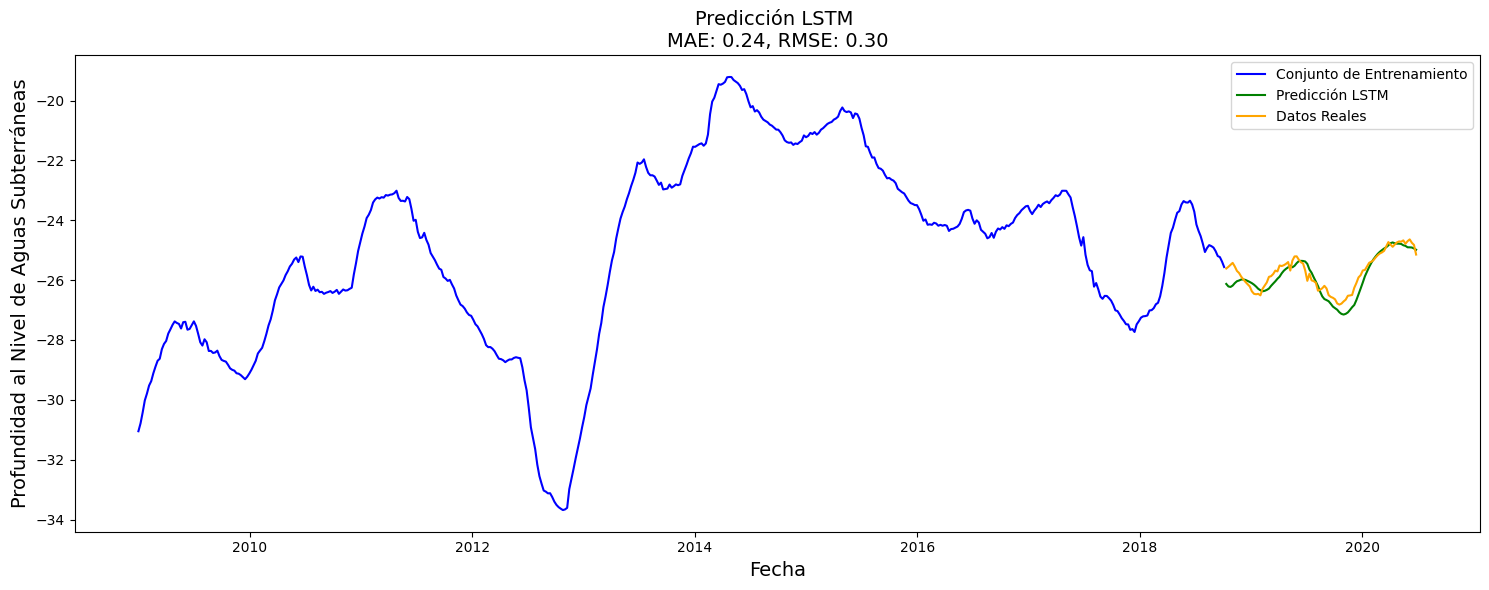

In [65]:
# -----------------------------------------------------------
# Paso 4: Graficar la predicción junto con los datos reales y el conjunto de entrenamiento
# -----------------------------------------------------------

# Extraer las fechas y los valores originales del DataFrame univariante
x_train_ticks = univariate_df.head(train_size)['ds']
y_train_data  = univariate_df.head(train_size)['y']

# Extraer las fechas para el conjunto de validación (prueba)
x_test_ticks  = univariate_df.tail(test_size)['ds']

# Crear la figura para la visualización
f, ax = plt.subplots(1, figsize=(15, 6))

# Graficar el conjunto de entrenamiento (datos históricos)
sns.lineplot(x=x_train_ticks, y=y_train_data, ax=ax, label='Conjunto de Entrenamiento', color='blue')

# Graficar la predicción del modelo (valores pronosticados) en el conjunto de validación
sns.lineplot(x=x_test_ticks, y=test_predict[:, 0], ax=ax, label='Predicción LSTM', color='green')

# Graficar los valores reales del conjunto de validación (ground truth)
sns.lineplot(x=x_test_ticks, y=y_test_inv[0], ax=ax, label='Datos Reales', color='orange')

# Configurar título y etiquetas
ax.set_title(f'Predicción LSTM \nMAE: {score_mae:.2f}, RMSE: {score_rmse:.2f}', fontsize=14)
ax.set_xlabel('Fecha', fontsize=14)
ax.set_ylabel('Profundidad al Nivel de Aguas Subterráneas', fontsize=14)

plt.tight_layout()
plt.show()

### Explicación

1. **Construcción del Modelo LSTM:**
   - Se crea un modelo secuencial para construir la red paso a paso.
   - La primera capa LSTM tiene 128 unidades y se le indica que devuelva secuencias completas (`return_sequences=True`) para poder apilar otra capa LSTM. Se define la forma de entrada con el número de pasos temporales y características.
   - La segunda capa LSTM, con 64 unidades, no devuelve secuencias (`return_sequences=False`), lo que significa que solo se utiliza la salida del último paso de tiempo.
   - Se añaden dos capas densas: una intermedia con 25 neuronas y otra final con 1 neurona, la cual genera el valor de predicción.

2. **Compilación del Modelo:**
   - El modelo se compila utilizando el optimizador **adam**, que es eficiente para el entrenamiento de redes neuronales.
   - La función de pérdida es el **mean squared error (MSE)**, apropiada para problemas de regresión.

3. **Entrenamiento:**
   - Se entrena el modelo usando los conjuntos de datos de entrenamiento (`x_train`, `y_train`) y se valida con (`x_test`, `y_test`).
   - Un tamaño de batch de 1 y 5 épocas de entrenamiento se emplean para ajustar los pesos de la red.

4. **Resumen del Modelo:**
   - Finalmente, `modelo.summary()` muestra una descripción detallada de la arquitectura del modelo, incluyendo la cantidad de parámetros entrenables en cada capa.

Este proceso prepara y entrena una red LSTM multicapas para pronosticar la siguiente observación de una serie de tiempo, aprovechando la estructura temporal que han sido preprocesada y reestructurada en pasos anteriores.


## LSTM Multivariante

In [66]:
# --------------------------------------------------------------------------------
# Paso 1: Preparar el DataFrame Multivariante
# --------------------------------------------------------------------------------
# Suponemos que 'df' tiene las siguientes columnas:
# 'fecha', 'lluvia', 'temperatura', 'volumen_drenaje', 'hidrometría_río',
# 'profundidad_al_nivel_de_aguas_subterráneas'
# Queremos predecir "profundidad_al_nivel_de_aguas_subterráneas" usando todas las variables
# como características (features).
# Seleccionamos las columnas relevantes y las convertimos a float.
multivar_df = df[['lluvia', 'temperatura', 'volumen_drenaje', 'hidrometría_río', 'profundidad_al_nivel_de_aguas_subterráneas']].astype('float32')

# --------------------------------------------------------------------------------
# Paso 2: Normalizar las características
# --------------------------------------------------------------------------------
# Se usa MinMaxScaler para escalar todas las variables al rango (-1, 0)
scaler = MinMaxScaler(feature_range=(-1, 0))
scaled_data = scaler.fit_transform(multivar_df.values)

# --------------------------------------------------------------------------------
# Paso 3: Crear el Dataset con Ventana Móvil (Look Back) para LSTM Multivariante
# --------------------------------------------------------------------------------
look_back = 52  # Por ejemplo, usar 52 períodos anteriores (podrían representar semanas o meses, según la serie)

def create_dataset_multivariate(dataset, look_back, target_index):
    """
    Crea dos arrays: X y Y, a partir de un dataset multivariante.
    X consiste en ventanas de datos de tamaño 'look_back' (todos los features).
    Y es el valor objetivo en el momento siguiente (usando el índice target_index del dataset original).
    """
    X, Y = [], []
    for i in range(look_back, len(dataset)):
        # Selecciona una ventana de datos de tamaño 'look_back' (todos los features)
        X.append(dataset[i - look_back:i, :])
        # El objetivo es el valor en la posición i de la columna target (en este caso, la última columna)
        Y.append(dataset[i, target_index])
    return np.array(X), np.array(Y)

# Suponiendo que la variable objetivo es la última columna (índice 4)
X, Y = create_dataset_multivariate(scaled_data, look_back, target_index=4)

# --------------------------------------------------------------------------------
# Paso 4: Dividir en Conjuntos de Entrenamiento y Prueba
# --------------------------------------------------------------------------------
train_size = int(0.85 * len(X))
test_size = len(X) - train_size

x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

print("Número de muestras de entrenamiento:", x_train.shape[0])
print("Número de muestras de prueba:", x_test.shape[0])

Número de muestras de entrenamiento: 465
Número de muestras de prueba: 83


In [67]:
# --------------------------------------------------------------------------------
# Paso 5: Construir y Entrenar el Modelo LSTM Multivariante
# --------------------------------------------------------------------------------
modelo = Sequential()
# Primera capa LSTM: 128 unidades, se devuelve toda la secuencia para poder apilar otra capa LSTM.
modelo.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
# Segunda capa LSTM: 64 unidades, devuelve sólo la salida final.
modelo.add(LSTM(64, return_sequences=False))
# Capa densa intermedia con 25 neuronas
modelo.add(Dense(25))
# Capa de salida con 1 neurona (la predicción de la profundidad)
modelo.add(Dense(1))

# Compilar el modelo usando el optimizador Adam y MSE como función de pérdida.
modelo.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
modelo.fit(x_train, y_train, batch_size=1, epochs=5, validation_data=(x_test, y_test))

# --------------------------------------------------------------------------------
# Paso 6: Obtener Predicciones y Evaluar el Modelo
# --------------------------------------------------------------------------------
# Predecir en el conjunto de prueba
test_predict = modelo.predict(x_test)

# --------------------------------------------------------------------------------
# Paso 7: Invertir la Escalación para Interpretar los Resultados
# --------------------------------------------------------------------------------
# Como todas las variables se escalaron juntas, extraer el escalado de la variable objetivo.
# Para ello, creamos un scaler específico para la variable "profundidad_al_nivel_de_aguas_subterráneas".
scaler_target = MinMaxScaler(feature_range=(-1, 0))
scaler_target.fit(multivar_df[['profundidad_al_nivel_de_aguas_subterráneas']])

# Invertir la normalización de los datos reales y de la predicción.
y_test_inv = scaler_target.inverse_transform(y_test.reshape(-1, 1))
test_predict_inv = scaler_target.inverse_transform(test_predict)

# Calcular métricas de desempeño (RMSE y MAE)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

score_mae = mean_absolute_error(y_test_inv, test_predict_inv)
score_rmse = math.sqrt(mean_squared_error(y_test_inv, test_predict_inv))
print(f"MAE: {score_mae:.2f}, RMSE: {score_rmse:.2f}")

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



465/465 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - loss: 0.0119 - val_loss: 0.0062
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - loss: 0.0020 - val_loss: 2.4998e-04
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.0012 - val_loss: 6.1544e-04
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - loss: 6.4071e-04 - val_loss: 2.0768e-04
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - loss: 6.4915e-04 - val_loss: 2.7717e-04
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step
MAE: 0.19, RMSE: 0.24


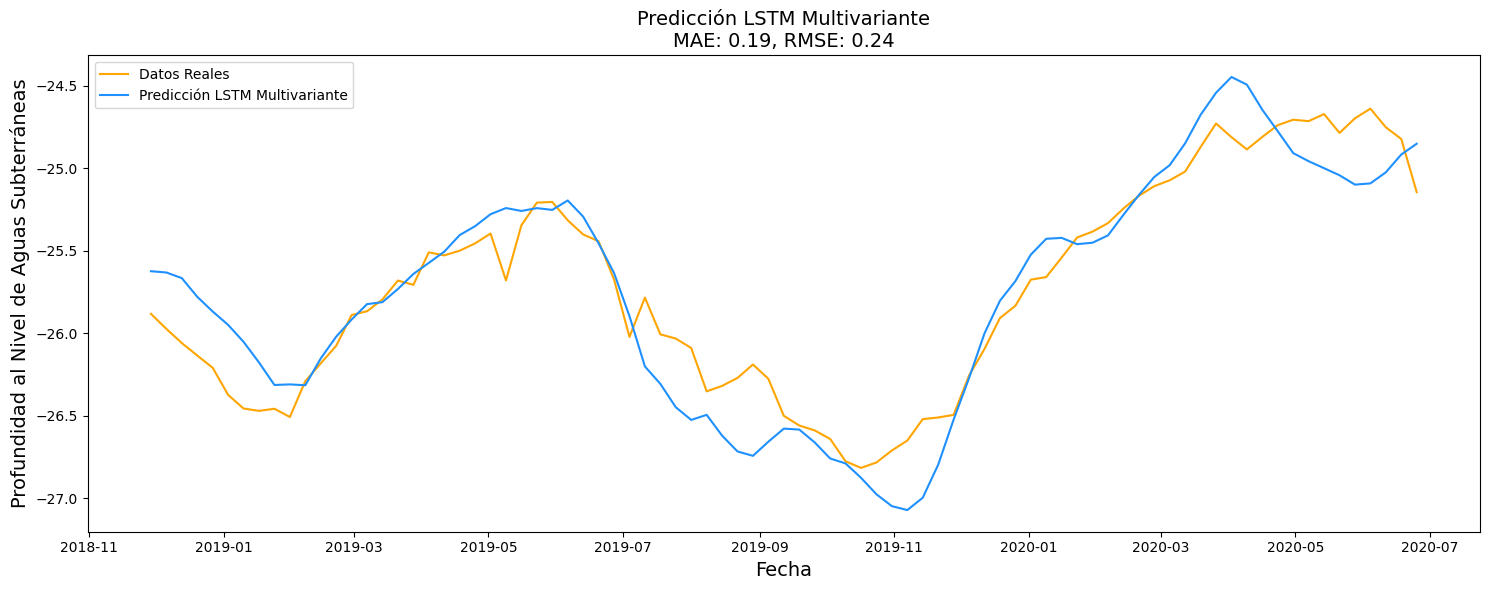

In [68]:
# --------------------------------------------------------------------------------
# Paso 8: Visualizar los Resultados
# --------------------------------------------------------------------------------
# Para asociar las predicciones a fechas, se debe tener en cuenta que, al crear las ventanas (look_back),
# se han perdido los primeros 'look_back' registros. Así, usamos las fechas a partir del índice (train_size + look_back)
x_test_ticks = df['fecha'].iloc[train_size + look_back:]

plt.figure(figsize=(15, 6))
# Graficar los datos reales del conjunto de prueba
sns.lineplot(x=x_test_ticks, y=y_test_inv[:, 0], label='Datos Reales', color='orange')
# Graficar las predicciones del modelo LSTM multivariante
sns.lineplot(x=x_test_ticks, y=test_predict_inv[:, 0], label='Predicción LSTM Multivariante', color='dodgerblue')

plt.title(f'Predicción LSTM Multivariante\nMAE: {score_mae:.2f}, RMSE: {score_rmse:.2f}', fontsize=14)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Profundidad al Nivel de Aguas Subterráneas', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## ¿Se considera ARIMA como Machine Learning?

**No del todo.** ARIMA es un modelo **estadístico tradicional**, no un algoritmo de *machine learning* en el sentido moderno. Pertenece al campo de la econometría y el análisis clásico de series de tiempo.

### Diferencias clave:

| Aspecto | ARIMA | Machine Learning |
|--------|-------|------------------|
| Tipo de modelo | Estadístico | Algoritmos computacionales |
| Supuestos | Requiere estacionariedad, linealidad | No siempre requiere supuestos fuertes |
| Interpretabilidad | Alta (modelo interpretable) | Baja o media (dependiendo del algoritmo) |
| Datos de entrada | Solo valores pasados de la misma variable (univariado) | Puede usar muchas variables (multivariado) |
| Predicción | A corto o mediano plazo, basado en patrones pasados | Flexible, incluso para problemas no lineales y de alto nivel de complejidad |

---

## ¿Por qué no se usa Machine Learning aquí?

Aunque podrías usar *machine learning* para series de tiempo, **no siempre es la mejor opción en etapas exploratorias** o cuando:

1. **Tienes poca cantidad de datos** (los modelos de ML suelen necesitar muchos datos para generalizar bien).
2. **Buscas interpretabilidad** para entender tendencias, estacionalidad y relaciones temporales (ARIMA es muy claro en esto).
3. **La variable depende principalmente de su propio historial** y no de muchas otras variables (ARIMA es excelente en problemas univariados).

---

## ¿Cuándo sí usar Machine Learning en series de tiempo?

- Cuando tienes **muchas variables externas** que influyen en la variable objetivo.
- Cuando el comportamiento del sistema es **altamente no lineal** o complejo.
- Cuando los modelos tradicionales no alcanzan buen rendimiento.
- Cuando quieres **detectar patrones más complejos**, como anomalías, comportamiento estacional múltiple o cambios estructurales.

---

En resumen:  
> ARIMA es una excelente herramienta para comenzar con análisis de series de tiempo y tiene la ventaja de ser simple, interpretable y eficaz cuando los supuestos se cumplen. Machine learning se reserva para problemas más complejos o multivariados.


## Referencias útiles sobre series temporales

- Referencia especial por la información y gráficos útiles: [Intro to Time Series Forecasting - Kaggle](https://www.kaggle.com/iamleonie/intro-to-time-series-forecasting)

### Modelos de series temporales:

- **ARIMA**: [Pronóstico de series temporales con modelos ARIMA - Towards Data Science](https://towardsdatascience.com/time-series-forecasting-arima-models-7f221e9eee06)

- **Auto-ARIMA**: [Guía de ARIMA automático en Python - Machine Learning Plus](https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/)

- **Keras LSTM**: [Predicción de series temporales con redes neuronales LSTM en Keras - Machine Learning Mastery](https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/)

- **Prophet**: [Predicción de series temporales usando Prophet en Python - Towards Data Science](https://towardsdatascience.com/time-series-prediction-using-prophet-in-python-35d65f626236)

- **Referencia especial a los modelos**: [Sección de modelos en el notebook de Kaggle](https://www.kaggle.com/iamleonie/intro-to-time-series-forecasting/notebook#Models)

### Temas complementarios:

- **Características cíclicas**: [Codificación de características cíclicas - Towards Data Science](https://towardsdatascience.com/cyclical-features-encoding-its-about-time-ce23581845ca)

- **Prueba ADF**: [Importancia de la prueba ADF en análisis de series temporales - Medium](https://medium.com/@cmukesh8688/why-is-augmented-dickey-fuller-test-adf-test-so-important-in-time-series-analysis-6fc97c6be2f0)

- **ACF/PACF**: [Significado de los gráficos ACF y PACF - Towards Data Science](https://towardsdatascience.com/significance-of-acf-and-pacf-plots-in-time-series-analysis-2fa11a5d10a8)

- **LSTM**: [Análisis, visualización y predicción de series temporales con LSTM - Towards Data Science](https://towardsdatascience.com/time-series-analysis-visualization-forecasting-with-lstm-77a905180eba)
